# 🤖 04. LLM Assistant for Multimodal Root Cause Analysis (RCA) Diagnosis
**Multi-Model Comparative Benchmark (`gemini-3.5-flash`, `gemini-3.1-flash-lite`, `deepseek-r1:14b`), Prompt Auditability, and Empirical Demonstration of NeuralLog**

---

### 📌 1. Theoretical Context and Role of the LLM Assistant in the Master's Thesis

In the preceding stages of this Master's Thesis, we developed and evaluated specialized observability components:
1. **Time Series (Metrics):** The **TranAD+** model (*Step 2*) detected anomaly time windows and identified metrics exhibiting the highest reconstruction deviations ($c_{t,i}$).
2. **Topology and Lineage (DAG Graph):** The **Topology Mapper** module mapped metrics with high reconstruction error to suspect components and tasks across the distributed architecture (Emitter $	o$ Kinesis $	o$ Airflow $	o$ PostgreSQL DW).
3. **Textual Log Evidence (Dense NLP):** The **NeuralLog** algorithm (*Step 3*) filtered over $97.6\%$ of routine background noise (`INFO` messages) and isolated the **Top-$K$ most anomalous logs** using dense semantic representations.

However, these three components produce heterogeneous, fragmented evidence. The core objective of this **Notebook 4** is to implement and empirically benchmark the **Root Cause Analysis (RCA) Assistant** powered by Large Language Models (**LLMs**), serving as the **multimodal synthesis and causal reasoning engine**:

```
+-----------------------------------------------------------------------------------------------+
|                                MULTIMODAL AIOps ARCHITECTURE                                  |
+-----------------------------------------------------------------------------------------------+
|  1. METRICS (TranAD+)            2. GRAPH / LINEAGE (Topology)     3. LOGS (NeuralLog)        |
|     - Window [T_start, T_end]       - Candidate mapping               - Top-K anomalous logs  |
|     - Variable deviations           - Flow propagation                - Noise discarded (>97%)|
+----------------------------------------+------------------------------------+-----------------+
                                         |
                                         v
+-----------------------------------------------------------------------------------------------+
|                     4. ROOT CAUSE LLM ASSISTANT (THIS NOTEBOOK 4)                             |
|                                                                                               |
|  - Collapsible viewer (<details>) of exact multimodal prompts for on-demand SRE auditability  |
|  - Comparative Multi-Model Benchmark evaluating 3 LLMs across the 3 benchmark incidents:     |
|      1) gemini-3.5-flash: Frontier Cloud model with reflective causal reasoning (CoT)         |
|      2) gemini-3.1-flash-lite: Cloud model optimized for ultra-low latency and high triage    |
|      3) deepseek-r1:14b: Open-Source On-Premises model on local GPU via Ollama (Data Privacy) |
|  - Objective quantitative evaluation across 4 dimensions against official Ground Truth        |
|  - Per-incident comparison table and final aggregated summary matrix                          |
|  - Automated Winning LLM selection                                                            |
|  - Ablation Study on Winning LLM: Empirical Demonstration of NeuralLog Value                  |
+-----------------------------------------------------------------------------------------------+
```

---

### 🔬 2. Design Principles of the LLM Assistant

1. **Provider-Agnostic Abstraction (`llm_client.py`):** Unifies invocation across commercial cloud APIs (Google Gemini via the official `google-genai` SDK) and local open-weight models (`deepseek-r1:14b` via Ollama over LiteLLM).
2. **Strict Credential Security:** All API keys are managed through environment variables and `.env` files (loaded via `python-dotenv`). No sensitive tokens are exposed in code or execution outputs.
3. **Clean Yet Auditable Prompt Inspection:** Assembled multimodal prompts are rendered in the Jupyter interface using collapsible HTML elements (`<details>`), kept collapsed by default to preserve readability while remaining accessible with a single click.
4. **Reasoning Chain Isolation (*Chain-of-Thought*):** Reflective models (`gemini-3.5-flash`, `deepseek-r1:14b`) generate extensive internal reasoning. Our architecture decouples intermediate thought tokens from the executive technical report, enabling SRE operators to inspect causal reasoning traces in interactive accordions without cluttering the final incident diagnosis.

## ⚙️ 1. Multi-Model Benchmark Definition and Secure Credential Loading

To objectively evaluate which model offers the optimal balance between **diagnostic accuracy**, **response latency**, **causal depth**, and **operational viability**, we configure three representative models spanning distinct architectural paradigms:

| Model | Provider | Paradigm / Role | Rationale for AIOps |
| :--- | :--- | :--- | :--- |
| **`gemini-3.5-flash`** | Google Gemini (Cloud) | *Cloud Frontier Reasoning* | Native reflective reasoning (*Chain-of-Thought*), deep causal deduction, and strict adherence to SRE guidelines. |
| **`gemini-3.1-flash-lite`** | Google Gemini (Cloud) | *Cloud Low-Latency Triage* | Engineered for extreme speed and low token consumption. Ideal for real-time preliminary triage. |
| **`deepseek-r1:14b`** | Ollama (Local GPU) | *Open-Source On-Premises* | Full data sovereignty and zero marginal API cost. Allows processing proprietary telemetry and confidential logs strictly within the corporate perimeter. |

> [!IMPORTANT]
> **Token Budget and Rate Limiting Delays:**
> - In reasoning models, internal thinking tokens and the final completion share the overall output quota (`max_output_tokens`). We configure `max_tokens: 4096` to prevent unintentional truncation (`MAX_TOKENS`).
> - A polite pause (`time.sleep(5)`) is enforced between consecutive API calls to comply with rate quotas on Google AI Studio Free Tier and mitigate `429 Too Many Requests` or `503 High Demand` errors.

In [25]:
import os

# =============================================================================
# ⚙️ MULTI-MODEL COMPARATIVE BENCHMARK CONFIGURATION (3 LLMs)
# =============================================================================

BENCHMARK_MODELS = [
    {
        "model_id": "gemini-3.5-flash",
        "provider": "gemini",
        "display_name": "Gemini 3.5 Flash",
        "role": "Cloud Reasoning (Reflective CoT)",
        "temperature": 0.2,
        "max_tokens": 4096,
        "timeout": 180
    },
    {
        "model_id": "gemini-3.1-flash-lite",
        "provider": "gemini",
        "display_name": "Gemini 3.1 Flash-Lite",
        "role": "Cloud Fast (Low Latency / Triage)",
        "temperature": 0.2,
        "max_tokens": 4096,
        "timeout": 180
    },
    {
        "model_id": "deepseek-r1:14b",
        "provider": "ollama",
        "display_name": "DeepSeek-R1:14b",
        "role": "Local GPU On-Prem (Full Privacy)",
        "temperature": 0.2,
        "max_tokens": 4096,
        "timeout": 300,
        "api_base": "http://localhost:11434"
    }
]

# =============================================================================
# ⚖️ BLIND EVALUATOR CONFIGURATION (LLM-AS-A-JUDGE)
# =============================================================================
# Impartial SRE Judge model assigned to evaluate diagnoses against Ground Truth.
JUDGE_MODEL_ID = "gemini-3.1-flash-lite"

POLITE_SLEEP_SECONDS = 5  # Pause between API calls to prevent saturation and 429 errors

# =============================================================================
# 📁 OUTPUT DIRECTORY FOR NOTEBOOK 4 ARTIFACTS
# =============================================================================
OUTPUT_DIR = "llms_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CACHE_FILE_PATH = os.path.join(OUTPUT_DIR, "cached_llm_responses.json")

# Automatic migration if previous cache exists in processed_data
legacy_cache_path = "processed_data/cached_llm_responses.json"
if not os.path.exists(CACHE_FILE_PATH) and os.path.exists(legacy_cache_path):
    import shutil
    shutil.copyfile(legacy_cache_path, CACHE_FILE_PATH)
    print(f"📦 Legacy cache automatically migrated to: {CACHE_FILE_PATH}")

def _atomic_update_cache(update_fn):
    # Atomically updates the cache file in llms_output/cached_llm_responses.json
    # using a temporary file (.tmp) and atomic replace to prevent corruption.
    cache_path = CACHE_FILE_PATH
    data = {}
    if os.path.exists(cache_path):
        try:
            with open(cache_path, "r", encoding="utf-8") as fc:
                data = json.load(fc)
        except Exception:
            data = {}
    
    update_fn(data)
    
    tmp_path = f"{cache_path}.tmp"
    with open(tmp_path, "w", encoding="utf-8") as fc:
        json.dump(data, fc, indent=2, ensure_ascii=False)
    os.replace(tmp_path, cache_path)

# =============================================================================
# ⚙️ LLM INFERENCE CACHE CONTROL
# =============================================================================
# Set to True to reuse verified cached responses (reproducibility and speed).
# Set to False to force live API calls to LLM providers.
# NOTE: Even with USE_CACHED_LLM_RESPONSES = False, all generated responses
# and Judge evaluations are ALWAYS saved to llms_output/cached_llm_responses.json
# (atomic write-through pattern call-by-call).
USE_CACHED_LLM_RESPONSES = True

print(f"📁 Artifacts directory configured: '{OUTPUT_DIR}/'")
print(f"💾 Central cache configured: '{CACHE_FILE_PATH}' (Mode: {'Read/Write' if USE_CACHED_LLM_RESPONSES else 'Fresh Write-Through'})")
print(f"⚖️ SRE Judge (LLM-as-a-Judge) configured: '{JUDGE_MODEL_ID}' (deterministic temperature=0.0)")
print(f"✅ Multi-Model Benchmark configured ({len(BENCHMARK_MODELS)} models):")
for m in BENCHMARK_MODELS:
    endpoint_str = m.get("api_base", "Google Cloud API (.env)")
    print(f"   • {m['display_name']:<22} | Provider: {m['provider']:<8} | Endpoint: {endpoint_str:<26} | Role: {m['role']}")

📁 Artifacts directory configured: 'llms_output/'
💾 Central cache configured: 'llms_output/cached_llm_responses.json' (Mode: Read/Write)
⚖️ SRE Judge (LLM-as-a-Judge) configured: 'gemini-3.1-flash-lite' (deterministic temperature=0.0)
✅ Multi-Model Benchmark configured (3 models):
   • Gemini 3.5 Flash       | Provider: gemini   | Endpoint: Google Cloud API (.env)    | Role: Cloud Reasoning (Reflective CoT)
   • Gemini 3.1 Flash-Lite  | Provider: gemini   | Endpoint: Google Cloud API (.env)    | Role: Cloud Fast (Low Latency / Triage)
   • DeepSeek-R1:14b        | Provider: ollama   | Endpoint: http://localhost:11434     | Role: Local GPU On-Prem (Full Privacy)


## 🔌 2. Unified Abstraction Layer with LiteLLM and `llm_client.py`

The [`llm_client.py`](file://llm_client.py) module encapsulates provider-specific communication complexities:
1. **Rich Markdown Rendering:** Implements a `.display()` method leveraging `IPython.display.Markdown` to render headers, bullet points, code blocks, and bold text natively.
2. **CoT Extraction and Decoupling:** Separates internal thinking traces (`candidate.parts.thought` in Gemini and `<think>` tags in DeepSeek) from the final report, preserving clean executive outputs while retaining full auditability.
3. **Preamble Purging:** Strips conversational pleasantries and conversational filler to enforce consistent, professional technical incident reports.

Below, we initialize unified client wrappers for each benchmark model and execute a lightweight smoke test to verify platform connectivity.

In [26]:
import os
import json
import time
import logging
logging.getLogger("google").setLevel(logging.ERROR)
logging.getLogger("google.genai").setLevel(logging.ERROR)
logging.getLogger("google.genai.models").setLevel(logging.ERROR)
logging.getLogger("google_genai").setLevel(logging.ERROR)
logging.getLogger("google_genai.models").setLevel(logging.ERROR)
from IPython.display import display, Markdown, HTML
from llm_client import UnifiedLLMClient, LLMResponse

# 1. Initialize unified clients for each benchmark model
clients = {}
print("🔌 Initializing unified clients for benchmark...")

for m_cfg in BENCHMARK_MODELS:
    m_id = m_cfg["model_id"]
    client = UnifiedLLMClient(
        provider=m_cfg["provider"],
        model=m_id,
        api_base=m_cfg.get("api_base"),
        temperature=m_cfg["temperature"],
        max_tokens=m_cfg["max_tokens"],
        timeout=m_cfg["timeout"]
    )
    clients[m_id] = client
    cfg_safe = client.get_safe_config()
    print(f"  ✓ {m_cfg['display_name']:<22}: provider={cfg_safe['provider']:<8} | key_ok={str(cfg_safe['api_key_configured']):<5} | endpoint={cfg_safe['api_base'] or 'Google Cloud API'}")

# Ensure judge model is initialized in clients dictionary
if JUDGE_MODEL_ID not in clients:
    judge_provider = "gemini" if "gemini" in JUDGE_MODEL_ID else "ollama"
    clients[JUDGE_MODEL_ID] = UnifiedLLMClient(
        provider=judge_provider,
        model=JUDGE_MODEL_ID,
        temperature=0.0
    )
    print(f"  ✓ SRE Judge ({JUDGE_MODEL_ID}): initialized as independent evaluator.")

# 2. Quick connectivity smoke test with SRE Judge
print(f"\\n⚡ Running smoke test with SRE Judge '{JUDGE_MODEL_ID}'...")
smoke_prompt = "Calculate 2+2 and answer exactly in this format:\\n### 1. Diagnosis\\nThe result of the operation is **4**."
try:
    smoke_resp = clients[JUDGE_MODEL_ID].generate(
        user_prompt=smoke_prompt,
        system_prompt="You are a concise observability and SRE assistant."
    )
    print(f"⏱️ Response latency: {smoke_resp.latency_seconds:.2f}s | Tokens: {smoke_resp.total_tokens}")
    print(f"🧠 Intermediate reasoning (CoT) detected: {'Yes (' + str(len(smoke_resp.thinking)) + ' chars)' if smoke_resp.thinking else 'No'}")
    print("\\n📋 Rendered Markdown Output:")
    smoke_resp.display()
except Exception as e:
    print(f"⚠️ Connectivity note in smoke test: {e}")
time.sleep(POLITE_SLEEP_SECONDS)

🔌 Initializing unified clients for benchmark...
  ✓ Gemini 3.5 Flash      : provider=gemini   | key_ok=True  | endpoint=Google Cloud API
  ✓ Gemini 3.1 Flash-Lite : provider=gemini   | key_ok=True  | endpoint=Google Cloud API
  ✓ DeepSeek-R1:14b       : provider=ollama   | key_ok=False | endpoint=http://localhost:11434

⚡ Running smoke test with SRE Judge 'gemini-3.1-flash-lite'...
⏱️ Response latency: 1.04s | Tokens: 60
🧠 Intermediate reasoning (CoT) detected: No

📋 Rendered Markdown Output:


### 1. Diagnosis
The result of the operation is **4**.

## 📦 3. Ingestion of the Multimodal Diagnostic Packet

We load structured diagnostic evidence generated during earlier thesis pipeline stages:
- **`processed_data/selected_relevant_logs_for_rca.json`**: Contains test set incidents with timestamps, anomalous metrics flagged by **TranAD+**, topological candidates identified by the **Topology Mapper**, and the **Top-$K$ most relevant logs** ranked by **NeuralLog**.
- **`dataset_gen/datasets_finales/test_rca_benchmark.json`**: Official Ground Truth used to benchmark diagnostic accuracy.
- **`dataset_gen/topology_mapper.py`**: Pipeline lineage DAG enriching contextual system knowledge.

In [27]:
import pandas as pd
from dataset_gen.topology_mapper import DATA_PIPELINE_DAG, ANOMALY_GROUND_TRUTH, get_components_for_metrics

# 1. Load test incidents prepared by TranAD+ and NeuralLog
with open("processed_data/selected_relevant_logs_for_rca.json", "r", encoding="utf-8") as f:
    rca_incidents = json.load(f)

# 2. Load benchmark with root cause Ground Truth (exclusively for rubric evaluation)
with open("dataset_gen/datasets_finales/test_rca_benchmark.json", "r", encoding="utf-8") as f:
    benchmark_cases = json.load(f)

# 3. Operational quantitative enrichment via TranAD+ inference
# METHODOLOGICAL INTEGRITY NOTE (No Data Leakage):
# We read only columns produced during inference by the neural network (anomaly_score and contrib_*).
# The 'ground_truth' column in CSV is strictly ignored, simulating a production environment.
df_detections = pd.read_csv("processed_data/test_detections.csv")
contrib_cols = [c for c in df_detections.columns if c.startswith("contrib_")]

for inc in rca_incidents:
    s, e = inc["window"]["start_epoch"], inc["window"]["end_epoch"]
    sub = df_detections[(df_detections["timestamp"] >= s) & (df_detections["timestamp"] <= e)]
    if len(sub) > 0:
        mean_score = float(sub["anomaly_score"].mean())
        max_score = float(sub["anomaly_score"].max())
        contrib_means = sub[contrib_cols].mean()
        total_contrib = contrib_means.sum() if contrib_means.sum() > 0 else 1.0
        ranked_contribs = []
        for col, val in contrib_means.sort_values(ascending=False).head(4).items():
            metric_name = col.replace("contrib_", "")
            pct = (val / total_contrib) * 100.0
            ranked_contribs.append({
                "metric": metric_name,
                "error_value": round(float(val), 4),
                "contribution_pct": round(float(pct), 2)
            })
        inc["tranad_evidence"]["quantitative_metrics"] = {
            "mean_anomaly_score": round(mean_score, 3),
            "max_anomaly_score": round(max_score, 3),
            "top_metric_contributions": ranked_contribs
        }

print(f"✅ Multimodal packet loaded and operationally enriched: {len(rca_incidents)} evaluation incidents in Test.")

summary_rows = []
for inc in rca_incidents:
    qm = inc["tranad_evidence"].get("quantitative_metrics", {})
    top_c = qm.get("top_metric_contributions", [])
    top_c_str = ", ".join([f"{c['metric']} ({c['contribution_pct']}%)" for c in top_c[:2]])
    summary_rows.append({
        "Incident ID": inc["incident_id"],
        "Anomaly Type": inc["anomaly_type"],
        "Category": inc["category"],
        "Duration (s)": inc["window"]["duration_seconds"],
        "TranAD+ Score (Max/Mean)": f"{qm.get('max_anomaly_score', 0):.2f} / {qm.get('mean_anomaly_score', 0):.2f}",
        "TranAD+ Top Contribution": top_c_str,
        "NeuralLog Top Logs": len(inc["neurallog_top_logs"]),
        "Actual Root Cause (Ground Truth)": inc["ground_truth"]["root_cause_summary"]
    })

pd.set_option('display.max_colwidth', None)
display(pd.DataFrame(summary_rows))

✅ Multimodal packet loaded and operationally enriched: 3 evaluation incidents in Test.


,Incident ID,Anomaly Type,Category,Duration (s),TranAD+ Score (Max/Mean),TranAD+ Top Contribution,NeuralLog Top Logs,Actual Root Cause (Ground Truth)
0,incident_000,dw_timeout,DATABASE_UNAVAILABLE,686,0.55 / 0.23,"cpu_usage (44.94%), memory_usage (32.39%)",10,"Interrupción / pausa del contenedor PostgreSQL Data Warehouse (analytics_db) en el puerto 5432, impidiendo la persistencia de lotes."
1,incident_001,emitter_down,SOURCE_PRODUCER_FAILURE,949,0.51 / 0.25,"emitter_memory_usage (27.24%), cpu_usage (24.44%)",10,Detención silenciosa del microservicio emisor de datos (kinesis_emitter) que inyecta telemetría continua al stream de Kinesis.
2,incident_002,aws_down,MESSAGE_BROKER_UNAVAILABLE,653,21.88 / 2.48,"emitter_memory_usage (49.87%), memory_usage (26.48%)",10,"Pausa / congelación del contenedor AWS LocalStack (Kinesis endpoint), manifestado a nivel de proceso por saturación de CPU y bloqueo del bucle de eventos asíncronos (CPU starvation en kinesis_mock_server) impidiendo responder a peticiones HTTP en el puerto 4566."


## 📝 4. Structured Prompt Engineering and Collapsible Viewer

Generating reliable technical diagnoses requires three foundational *Prompt Engineering* methodologies:
1. **Specialized System Prompt:** Establishes the model's persona as a *Principal Data Engineer and SRE/Observability Specialist*, enforcing an invariant 3-section report structure:
   - **`### 1. Root Cause Diagnosis`**
   - **`### 2. Cascade Propagation Analysis (Downstream / Upstream Impact)`**
   - **`### 3. Technical Remediation Actions`**
2. **Operational Multimodal Fusion with Zero Data Leakage:**
   - **NeuralLog Top-10 Logs:** Ingests the 10 anomalous logs selected and diversified via Sentence-BERT + Isolation Forest. Artificial truncation to 5 logs is eliminated, allowing the LLM to observe critical downstream failure cascades and task termination traces (e.g., `TRIM_HORIZON` expiration and Airflow task failures).
   - **Quantitative TranAD+ Signals:** Incorporates peak and mean reconstruction error scores (`max_anomaly_score`, `mean_anomaly_score`) and variable error attribution rankings (`contrib_*`). These signals stem exclusively from unsupervised streaming model inference, completely avoiding Ground Truth contamination.
3. **Collapsible Prompt Viewer for SRE Auditability:** To enable operators to audit exact prompts dispatched to LLMs without cluttering the notebook interface, prompts are wrapped in an HTML `<details>` element, **collapsed by default** and expandable on demand.

In [28]:
import html

SYSTEM_PROMPT = """You are a Principal Data Engineer and SRE/Observability Specialist for Distributed Data Pipelines.
Your role is to perform Root Cause Analysis (RCA) and technical diagnosis of anomalies detected across a distributed data pipeline.

You will be provided with:
1. Pipeline DAG topology and data flow description.
2. Anomaly time window and metrics flagged by the time-series model (TranAD+) with high reconstruction error.
3. Candidate component logs within the time window (filtered and ranked by semantic relevance via NeuralLog).

You must generate a concise, structured report adhering to this EXACT format:
### 1. Root Cause Diagnosis
- Originating failure component.
- Exact failure reason grounded in log and metric evidence.

### 2. Cascade Propagation Analysis (Downstream / Upstream Impact)
- How this failure impacted dependent pipeline components across the data lineage (delays, consumer lag accumulation, record loss/lockup).

### 3. Technical Remediation Actions
- Immediate operational mitigations to resolve the active incident.
- Long-term preventive infrastructure or code hardening measures.
"""

def build_multimodal_rca_prompt(incident: dict, mode: str = "multimodal", raw_logs_sample: list = None) -> str:
    """
    Constructs the multimodal prompt combining topology, metrics, and logs.
    Supports 3 experimental modes for the ablation study:
      - 'multimodal': Topology + Quantitative TranAD+ + Top-10 logs selected by NeuralLog.
      - 'no_logs': Topology + Quantitative TranAD+ without logs (pure metric isolation).
      - 'raw_logs': Topology + Quantitative TranAD+ + raw routine INFO logs (without semantic filtering).
    """
    topo = incident["topology_context"]
    window = incident["window"]
    candidates = topo["candidate_components"]
    
    # 1. Quantitative operational TranAD+ evidence (no Ground Truth leakage)
    q_metrics = incident.get("tranad_evidence", {}).get("quantitative_metrics", {})
    max_score = q_metrics.get("max_anomaly_score", 0.0)
    mean_score = q_metrics.get("mean_anomaly_score", 0.0)
    top_contribs = q_metrics.get("top_metric_contributions", [])
    
    if top_contribs:
        contrib_lines = "\\n".join([
            f"  {idx+1}. {c['metric']}: {c['contribution_pct']}% of multivariate error (error: {c.get('error_value', 0):.4f})"
            for idx, c in enumerate(top_contribs)
        ])
    else:
        metrics = incident.get("tranad_evidence", {}).get("expected_anomalous_metrics", [])
        contrib_lines = f"  - Detected metrics: {', '.join(metrics)}"

    # 2. Textual Log Evidence
    if mode == "multimodal":
        logs = incident.get("neurallog_top_logs", [])
        log_lines = []
        for idx, l in enumerate(logs[:10], 1):
            score = l.get("anomaly_score", 0.0)
            log_lines.append(f"[{idx}] [{l['component']}] [{l['level']}] (Score: {score:.3f}) {l['message']}")
        logs_str = "\\n".join(log_lines) if log_lines else "(No relevant logs detected in window)"
    elif mode == "no_logs":
        logs_str = "(No textual log evidence available. Perform diagnosis relying exclusively on quantitative metrics and DAG topology)"
    elif mode == "raw_logs":
        logs = raw_logs_sample or []
        log_lines = [
            f"[{idx}] [{l.get('component', 'unknown')}] [{l.get('level', 'INFO')}] {l.get('message', '')}"
            for idx, l in enumerate(logs[:10], 1)
        ]
        logs_str = "\\n".join(log_lines) if log_lines else "(Routine system logs without explicit anomalies)"
    else:
        raise ValueError(f"Unknown mode: {mode}")

    prompt = f"""=== SYSTEM CONTEXT AND PIPELINE TOPOLOGY ===
Data Flow: {topo['flow_description']}
System Nodes: {json.dumps(list(DATA_PIPELINE_DAG['nodes'].keys()))}

=== ANOMALY ALERT AND DETECTION (TranAD+) ===
- Affected Time Window: {window['start_iso']} to {window['end_iso']} ({window['duration_seconds']} seconds)
- Quantitative Anomaly Magnitude: Max Score = {max_score:.3f} | Window Mean Score = {mean_score:.3f} (Nominal Baseline: < 0.200)
- Reconstruction Error Contribution Hierarchy (TranAD+ Unsupervised Attribution):
{contrib_lines}
- Candidate Components Flagged by Lineage: {', '.join(candidates)}

=== LOG EVIDENCE ({'NeuralLog Top-10 Relevant' if mode == 'multimodal' else mode.upper()}) ===
{logs_str}

=== REQUEST ===
Perform technical Root Cause Analysis (RCA), detailing root cause origin, cascade impact, and necessary mitigation actions.
"""
    return prompt


def display_collapsible_prompt(prompt_text: str, incident_id: str, anomaly_type: str):
    """
    Renders assembled prompt in an HTML collapsible element (<details>),
    collapsed by default to keep the interface clean while enabling on-demand auditability.
    """
    escaped_prompt = html.escape(prompt_text.strip())
    html_code = f"""<details style='margin-top: 10px; margin-bottom: 14px; border: 1px solid #cbd5e1; border-radius: 6px; padding: 10px 14px; background-color: #f8fafc;'>
<summary style='cursor: pointer; font-weight: 600; color: #1e3a8a; font-size: 0.95em;'>
🔍 <b>View Assembled Multimodal Prompt</b> for <code>{incident_id}</code> ({anomaly_type}) [Click to expand]
</summary>
<pre style='white-space: pre-wrap; font-family: monospace; font-size: 0.82em; color: #334155; margin-top: 10px; max-height: 360px; overflow-y: auto; background: #ffffff; padding: 12px; border-radius: 4px; border: 1px solid #e2e8f0;'>
{escaped_prompt}
</pre>
</details>"""
    display(HTML(html_code))

print("✅ Prompt Generator and Collapsible Viewer compiled successfully.")
print("\\n👁️ Interactive demonstration of collapsible viewer with first incident:")
demo_prompt = build_multimodal_rca_prompt(rca_incidents[0], mode="multimodal")
display_collapsible_prompt(demo_prompt, rca_incidents[0]["incident_id"], rca_incidents[0]["anomaly_type"])

✅ Prompt Generator and Collapsible Viewer compiled successfully.

👁️ Interactive demonstration of collapsible viewer with first incident:


## 📊 5. Rigorous Evaluation Paradigm: LLM-as-a-Judge with Multidimensional SRE Rubric

### 📚 1. Theoretical Rationale and Scientific Literature References

Evaluating unstructured technical incident reports and complex causal diagnoses generated by Large Language Models (LLMs) cannot be reliably addressed through keyword heuristics or regular expressions (*regex*). Lexical matching fails to capture causal directionality, conflates symptoms with root causes, and cannot assess architectural reasoning depth.

To ensure academic and operational rigor, this Master's Thesis implements the formal **LLM-as-a-Judge** paradigm, anchored in foundational research:

1. **Zheng, L., Chiang, W. L., Sheng, Y., Tian, S., Wang, H., Wang, J., ... & Stoica, I. (2023).**  
   *«Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena»*. *Advances in Neural Information Processing Systems (NeurIPS 2023)*.  
   > **Core Contribution:** Demonstrates that strong frontier language models achieve over 80% agreement with human domain experts when provided with structured evaluation protocols, establishing LLM-as-a-Judge as a state-of-the-art scalable evaluation methodology.

2. **Liu, Y., Iter, D., Xu, Y., Wang, S., Xu, R., & Zhu, C. (2023).**  
   *«G-Eval: NLG Evaluation using GPT-4 with Better Human Alignment»*. *Proceedings of the 2023 Conference on Empirical Methods in Natural Language Processing (EMNLP 2023)*.  
   > **Core Contribution:** Formalizes evaluation frameworks guided by **explicit multidimensional rubrics** and Chain-of-Thought prompting. Demonstrates that decomposing complex evaluation tasks into weighted dimensions maximizes alignment with human expert judgment.

3. **Kim, S., Suk, J., Zhao, H., Sanabria, M., Wang, Y., & Moosavi, M. (2024).**  
   *«Prometheus: Inducing Fine-grained Evaluation Capability in Language Models»*. *International Conference on Learning Representations (ICLR 2024)*.  
   > **Core Contribution:** Demonstrates that pairing a **fine-grained scoring rubric (*score rubric*) with reference Ground Truth** empowers evaluator models to deliver calibrated numerical ratings and transparent qualitative critiques.

4. **Dubois, Y., Li, C. X., Taori, R., Hashimoto, T., & Liang, P. (2024).**  
   *«AlpacaEval 2.0: An Automatable and High-Correlation Benchmark for Instruction-Following»*.  
   > **Core Contribution:** Formalizes **blind evaluation standards**, ensuring the evaluator remains unaware of model identity and provider to prevent self-enhancement or brand preference biases.

---

### ⚖️ 2. Blind Evaluation Protocol and 4-Dimensional SRE Rubric

We implement an independent SRE evaluation agent utilizing **`gemini-3.1-flash-lite`** as the judge model configured with deterministic temperature ($	ext{temperature} = 0.0$):
- **Blind Evaluation:** The judge receives the diagnostic text under the anonymized header `"TECHNICAL DIAGNOSIS ISSUED BY SRE ASSISTANT"`, with zero knowledge of the generating model (`gemini-3.5-flash`, `gemini-3.1-flash-lite`, or `deepseek-r1:14b`).
- **Strict Data Isolation:** The official Ground Truth is **supplied exclusively to the Judge**, maintaining strict separation from the assistant's inference prompt.
- **Weighted 4-Dimensional Rubric ($S \in [0.0, 1.0]$):**
  1. **Root Component Identification ($S_{\text{comp}}$, 35%):** Precision in pinpointing the true originating failure component defined in Ground Truth, penalizing confusion between the root cause and downstream victims.
  2. **Causal Failure Mechanism ($S_{\text{mechanism}}$, 30%):** Technical fidelity in explaining the exact root failure mechanism (e.g., database timeout, process crash, endpoint unavailability), rewarding technical depth grounded in log traces (CPU starvation, thread/event loop lockups).
  3. **Cascade Propagation and Lineage ($S_{\text{cascade}}$, 15%):** Rigor in detailing upstream/downstream impacts across DAG tasks and data lineage, evaluated against Ground Truth expected effects (upstream backpressure and downstream starvation).
  4. **Remediation Viability ($S_{\text{remediation}}$, 20%):** Operational feasibility, safety, and relevance of immediate mitigation and long-term preventive SRE recommendations.

$$
\text{Score}_{\text{Global}} = \left(0.35 \cdot S_{\text{comp}} + 0.30 \cdot S_{\text{mechanism}} + 0.15 \cdot S_{\text{cascade}} + 0.20 \cdot S_{\text{remediation}}\right) \times 100
$$

Beyond the numerical score, the evaluator emits a **structured qualitative critique** detailing specific justifications across each dimension, guaranteeing complete interpretability.

In [29]:
import json
import os
import re

JUDGE_SYSTEM_PROMPT = """You are a Principal Site Reliability Engineer (Principal SRE / Staff DevOps) and expert evaluator in AIOps observability.
Your mission is to objectively, rigorously, and critically evaluate an RCA diagnostic report generated by an AI assistant against the official Ground Truth of the incident.

You must apply a strict 4-dimensional rubric:
1. Affected Components (Weight: 35%): Accuracy in identifying root-cause failure components defined in Ground Truth. Penalize confusing root components with downstream victims.
2. Causal Failure Mechanism (Weight: 30%): Technical fidelity in explaining the exact root cause (e.g., DB timeout, emitter crash, AWS outage). Penalize vague explanations or symptoms confused with causes. Reward technical depth grounded in log traces (CPU starvation, thread/event loop lockups), distinguishing it from hallucinations.
3. Cascade Propagation and Lineage (Weight: 15%): Rigor in describing impact on dependent DAG tasks and data lineage. Contrast against 'Expected Cascade Effects' in Ground Truth. Reward deduction of bidirectional upstream effects (backpressure, buffer saturation) and downstream effects (data starvation to transform and load).
4. Remediation Viability (Weight: 20%): Quality, feasibility, and operational relevance of prescriptive actions (immediate and preventive).

CRITICAL INSTRUCTIONS:
- Your evaluation is completely BLIND and IMPARTIAL.
- Scores per dimension must be continuous floats in range [0.0, 1.0].
- Global score is calculated as:
  global_score = (0.35 * component_score + 0.30 * mechanism_score + 0.15 * cascade_score + 0.20 * remediation_score) * 100
- You MUST return a valid JSON object with the following exact structure:
{
  "component_score": <float 0.0 - 1.0>,
  "mechanism_score": <float 0.0 - 1.0>,
  "cascade_score": <float 0.0 - 1.0>,
  "remediation_score": <float 0.0 - 1.0>,
  "global_score": <float 0.0 - 100.0>,
  "critique": {
    "component_rationale": "<detailed justification>",
    "mechanism_rationale": "<detailed justification>",
    "cascade_rationale": "<detailed justification>",
    "remediation_rationale": "<detailed justification>"
  }
}
Do not return any text outside the JSON block. Strictly comply with RFC 8259: FORBIDDEN to include trailing commas before closing braces '}' or brackets ']'."""

def parse_llm_json_robustly(raw_text: str) -> dict:
    """
    Ultra-resilient JSON parser for LLM outputs, handling:
    1. Markdown code fences (```json or ```).
    2. Surrounding conversational text (preamble/postscript).
    3. Trailing commas before closing braces/brackets.
    4. Regex fallback extraction for rubric metrics.
    """
    text = raw_text.strip()
    
    # 1. Clean markdown code fences
    if text.startswith("```"):
        lines = text.split("\n")
        if lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        text = "\n".join(lines).strip()

    # 2. Extract outermost JSON block if conversational text exists
    s_idx = text.find("{")
    e_idx = text.rfind("}")
    if s_idx != -1 and e_idx != -1 and e_idx > s_idx:
        candidate = text[s_idx:e_idx+1]
        try:
            return json.loads(candidate, strict=False)
        except Exception:
            text = candidate

    # 3. Strip comments and trailing commas
    cleaned = re.sub(r'//.*', '', text)
    cleaned = re.sub(r'/\*[\s\S]*?\*/', '', cleaned)
    cleaned = re.sub(r',\s*([\}\]])', r'\1', cleaned)
    try:
        return json.loads(cleaned, strict=False)
    except Exception:
        pass

    # 4. Fallback regex extraction for rubric schema
    res = {}
    for key in ['component_score', 'mechanism_score', 'cascade_score', 'remediation_score', 'global_score']:
        m = re.search(rf'"{key}"\s*:\s*([0-9]*\.?[0-9]+)', text)
        if m:
            res[key] = float(m.group(1))
    
    critique = {}
    for r_key in ['component_rationale', 'mechanism_rationale', 'cascade_rationale', 'remediation_rationale']:
        m = re.search(rf'"{r_key}"\s*:\s*"([\s\S]*?)"(?=\s*,\s*"|\s*\}})', text)
        if m:
            critique[r_key] = m.group(1).replace('\\"', '"').strip()
        else:
            m2 = re.search(rf'"{r_key}"\s*:\s*"([^"]*)"', text)
            if m2:
                critique[r_key] = m2.group(1).strip()
            else:
                critique[r_key] = "Qualitative evaluation partially extracted."
    res['critique'] = critique
    return res

def evaluate_diagnostic_with_llm_judge(
    generated_text: str,
    ground_truth: dict,
    judge_client=None,
    cache_key: str = None
) -> dict:
    """
    Evaluates a diagnostic report using the LLM-as-a-Judge paradigm.
    Executes a blind evaluation against official Ground Truth using
    a structured 4-dimensional SRE rubric.
    """
    cache_file = globals().get("CACHE_FILE_PATH", "processed_data/cached_llm_responses.json")
    if not os.path.exists(cache_file) and os.path.exists("llms_output/cached_llm_responses.json"):
        cache_file = "llms_output/cached_llm_responses.json"
    use_cache = globals().get("USE_CACHED_LLM_RESPONSES", False)
    
    # 1. Cache lookup if available and reading enabled
    if use_cache and cache_key and os.path.exists(cache_file):
        try:
            with open(cache_file, "r", encoding="utf-8") as f:
                cdata = json.load(f)
                judge_cache = cdata.get("judge_evaluations", {})
                if cache_key in judge_cache:
                    return judge_cache[cache_key]
        except Exception:
            pass
            
    # 2. Live LLM Judge Inference
    judge_user_prompt = f"""BLIND SRE DIAGNOSTIC EVALUATION:

OFFICIAL INCIDENT GROUND TRUTH:
- Primary Origin Components: {ground_truth.get('primary_affected_components', [])}
- Root Cause Summary: {ground_truth.get('root_cause_summary', '')}
- Expected Cascade Effects: {ground_truth.get('expected_cascade_effects', '')}
- Recommended Remediations: {ground_truth.get('recommended_remediations', [])}

TECHNICAL DIAGNOSIS ISSUED BY SRE ASSISTANT (BLIND EVALUATION):
\"\"\"
{generated_text}
\"\"\"

Evaluate the diagnosis above against the official Ground Truth following the multidimensional rubric.
Return EXCLUSIVELY the structured JSON object adhering to RFC 8259 with no trailing commas."""

    if judge_client is None:
        judge_model_id = globals().get("JUDGE_MODEL_ID", "gemini-3.1-flash-lite")
        clients_dict = globals().get("clients", {})
        judge_client = clients_dict.get(judge_model_id)

    if judge_client is None:
        raise ValueError(f"judge_client unavailable for judge model '{globals().get('JUDGE_MODEL_ID', 'unknown')}'.")

    eval_result = None
    last_err = None

    for attempt in range(3):
        try:
            resp = judge_client.generate(
                user_prompt=judge_user_prompt,
                system_prompt=JUDGE_SYSTEM_PROMPT,
                temperature=0.0,
                json_mode=True
            )
            raw_text = resp.content.strip()
            eval_result = parse_llm_json_robustly(raw_text)
            if eval_result and "component_score" in eval_result:
                break
        except Exception as e:
            last_err = e
            if attempt < 2:
                time.sleep(2)

    if not eval_result:
        raise RuntimeError(f"Definitive failure parsing SRE judge verdict after 3 attempts: {last_err}")
    
    # Ensure required fields and correct numerical types
    eval_result["component_score"] = float(eval_result.get("component_score", 0.0))
    eval_result["mechanism_score"] = float(eval_result.get("mechanism_score", 0.0))
    eval_result["cascade_score"] = float(eval_result.get("cascade_score", 0.0))
    eval_result["remediation_score"] = float(eval_result.get("remediation_score", 0.0))
    
    calculated_global = (
        0.35 * eval_result["component_score"] +
        0.30 * eval_result["mechanism_score"] +
        0.15 * eval_result["cascade_score"] +
        0.20 * eval_result["remediation_score"]
    ) * 100.0
    eval_result["global_score"] = round(calculated_global, 1)

    # 3. Always write-through atomically to cache
    if cache_key:
        if "_atomic_update_cache" in globals():
            def save_judge(c):
                if "judge_evaluations" not in c:
                    c["judge_evaluations"] = {}
                c["judge_evaluations"][cache_key] = eval_result
            try:
                _atomic_update_cache(save_judge)
            except Exception as e:
                print(f"⚠️ Note: could not write judge verdict to cache: {e}")
        elif os.path.exists(cache_file):
            try:
                with open(cache_file, "r", encoding="utf-8") as f:
                    cdata = json.load(f)
                if "judge_evaluations" not in cdata:
                    cdata["judge_evaluations"] = {}
                cdata["judge_evaluations"][cache_key] = eval_result
                with open(cache_file, "w", encoding="utf-8") as f:
                    json.dump(cdata, f, indent=2, ensure_ascii=False)
            except Exception as e:
                print(f"⚠️ Note: could not write judge verdict to cache: {e}")

    return eval_result

def render_judge_critique_accordion(scores: dict, model_name: str = "Model") -> str:
    """Generates an HTML collapsible element containing detailed SRE Judge critique."""
    crit = scores.get("critique", {})
    return (
        f"<details style='margin-top: 8px; margin-bottom: 14px; border: 1px solid #cbd5e1; border-radius: 6px; padding: 9px 13px; background-color: #f8fafc;'>"
        f"<summary style='cursor: pointer; color: #1e3a8a; font-weight: bold; font-size: 0.94em;'>"
        f"⚖️ SRE Judge Qualitative Verdict (LLM-as-a-Judge) for {model_name} | Global Score: {scores['global_score']:.1f}% "
        f"(Comp: {scores['component_score']*100:.0f}%, Mech: {scores['mechanism_score']*100:.0f}%, Casc: {scores['cascade_score']*100:.0f}%, Rem: {scores['remediation_score']*100:.0f}%)"
        f"</summary>"
        f"<div style='margin-top: 10px; font-size: 0.89em; line-height: 1.55; color: #334155;'>"
        f"<p style='margin-bottom: 5px;'><b>🎯 Root Component ({scores['component_score']*100:.0f}%):</b> {crit.get('component_rationale', '-')}</p>"
        f"<p style='margin-bottom: 5px;'><b>⚙️ Causal Mechanism ({scores['mechanism_score']*100:.0f}%):</b> {crit.get('mechanism_rationale', '-')}</p>"
        f"<p style='margin-bottom: 5px;'><b>🌊 Cascade and Lineage ({scores['cascade_score']*100:.0f}%):</b> {crit.get('cascade_rationale', '-')}</p>"
        f"<p style='margin-bottom: 2px;'><b>🛠️ SRE Remediation ({scores['remediation_score']*100:.0f}%):</b> {crit.get('remediation_rationale', '-')}</p>"
        f"</div></details>"
    )

print("✅ LLM-as-a-Judge evaluator (blind multidimensional SRE rubric) configured successfully.")

✅ LLM-as-a-Judge evaluator (blind multidimensional SRE rubric) configured successfully.


## 🚀 6. Comparative Multi-Model Benchmark (3 LLMs × 3 Test Incidents)

We execute the complete diagnostic inference cycle across all 3 benchmark test incidents:
1. **`incident_000` (`dw_timeout`):** PostgreSQL Data Warehouse freeze / pause during the `load_task` stage.
2. **`incident_001` (`emitter_down`):** Silent crash of the data producer microservice feeding the Kinesis stream.
3. **`incident_002` (`aws_down`):** Interruption of the AWS LocalStack endpoint, triggering concurrent timeouts in the emitter and `extract_task`.

For each incident:
- Display the **assembled multimodal prompt in a collapsible viewer** (`<details>`).
- Sequentially query the 3 models (`gemini-3.5-flash`, `gemini-3.1-flash-lite`, `deepseek-r1:14b`).
- Render each model's report alongside its intermediate reasoning chain (CoT).
- Generate an **incident-specific quantitative comparison table** evaluating accuracy, latency, and token footprint.

In [30]:
# Benchmark result data structures
benchmark_results = {}  # model_id -> {inc_id -> {...}}
for m in BENCHMARK_MODELS:
    benchmark_results[m["model_id"]] = {}

incident_comparison_tables = {}

print("🚀 STARTING COMPARATIVE BENCHMARK: 3 LLMs × 3 TEST INCIDENTS\\n")

for idx, inc in enumerate(rca_incidents):
    inc_id = inc["incident_id"]
    inc_type = inc["anomaly_type"]
    gt = inc["ground_truth"]
    
    header_html = (
        f"<div style='margin-top: 25px; margin-bottom: 10px; padding: 12px 18px; "
        f"background: linear-gradient(90deg, #1e3a8a 0%, #3b82f6 100%); color: white; "
        f"border-radius: 8px; font-weight: bold; font-size: 1.15em;'>"
        f"🚨 INCIDENT {idx+1}/{len(rca_incidents)}: {inc_id} ({inc_type})</div>"
    )
    display(HTML(header_html))
    
    # 1. Build prompt and render collapsible viewer (collapsed by default)
    multimodal_prompt = build_multimodal_rca_prompt(inc, mode="multimodal")
    display_collapsible_prompt(multimodal_prompt, inc_id, inc_type)
    
    inc_records = []
    
    # 2. Evaluate each model on this incident
    for m_cfg in BENCHMARK_MODELS:
        m_id = m_cfg["model_id"]
        m_name = m_cfg["display_name"]
        client = clients[m_id]
        
        cached_data = None
        if os.path.exists(CACHE_FILE_PATH):
            try:
                with open(CACHE_FILE_PATH, "r", encoding="utf-8") as f_c:
                    cache_all = json.load(f_c)
                    for item in cache_all.get("benchmark", {}).get(m_id, []):
                        if item["incident_id"] == inc_id:
                            cached_data = item
                            break
            except Exception:
                pass

        use_cache = USE_CACHED_LLM_RESPONSES and (cached_data is not None)
        is_live = False

        if use_cache:
            print(f"📦 Loading verified cached response for '{m_name}' on {inc_id}...")
            meta = cached_data.get("llm_metadata", {})
            toks = meta.get("tokens", {})
            resp = LLMResponse(
                content=cached_data["diagnostic_report"],
                thinking=cached_data.get("chain_of_thought"),
                prompt_tokens=toks.get("prompt", 0),
                completion_tokens=toks.get("completion", 0),
                total_tokens=toks.get("total", 0),
                latency_seconds=meta.get("latency_seconds", 0.0),
                model=m_id,
                provider=m_cfg["provider"]
            )
        else:
            print(f"⏳ Evaluating '{m_name}' on {inc_id} (Live inference)...")
            try:
                resp = client.generate(user_prompt=multimodal_prompt, system_prompt=SYSTEM_PROMPT)
                is_live = True
            except Exception as e:
                print(f"⚠️ Live inference unavailable ({e}). Loading verified cached response...")
                if cached_data:
                    meta = cached_data.get("llm_metadata", {})
                    toks = meta.get("tokens", {})
                    resp = LLMResponse(
                        content=cached_data["diagnostic_report"],
                        thinking=cached_data.get("chain_of_thought"),
                        prompt_tokens=toks.get("prompt", 0),
                        completion_tokens=toks.get("completion", 0),
                        total_tokens=toks.get("total", 0),
                        latency_seconds=meta.get("latency_seconds", 0.0),
                        model=m_id,
                        provider=m_cfg["provider"]
                    )
                else:
                    raise e

        # Atomic write-through save for live inferences
        if is_live:
            def update_bench(c):
                if "benchmark" not in c:
                    c["benchmark"] = {}
                if m_id not in c["benchmark"]:
                    c["benchmark"][m_id] = []
                c["benchmark"][m_id] = [it for it in c["benchmark"][m_id] if it["incident_id"] != inc_id]
                c["benchmark"][m_id].append({
                    "incident_id": inc_id,
                    "anomaly_type": inc_type,
                    "diagnostic_report": resp.content,
                    "chain_of_thought": resp.thinking,
                    "llm_metadata": {
                        "model": m_id,
                        "provider": m_cfg["provider"],
                        "latency_seconds": resp.latency_seconds,
                        "tokens": {
                            "prompt": resp.prompt_tokens,
                            "completion": resp.completion_tokens,
                            "total": resp.total_tokens
                        }
                    }
                })
            try:
                _atomic_update_cache(update_bench)
            except Exception as e:
                print(f"⚠️ Note: could not save benchmark to cache: {e}")
        
        # Blind evaluation via LLM-as-a-Judge against Ground Truth
        judge_key = f"{m_id}_{inc_id}"
        scores = evaluate_diagnostic_with_llm_judge(
            generated_text=resp.content,
            ground_truth=gt,
            judge_client=clients.get(JUDGE_MODEL_ID),
            cache_key=judge_key
        )
        
        benchmark_results[m_id][inc_id] = {
            "incident_id": inc_id,
            "anomaly_type": inc_type,
            "response": resp,
            "scores": scores,
            "ground_truth": gt
        }
        
        inc_records.append({
            "Model": m_name,
            "Provider": m_cfg["provider"],
            "Root Comp.": f"{scores['component_score']*100:.0f}%",
            "Mechanism": f"{scores['mechanism_score']*100:.0f}%",
            "Cascade": f"{scores['cascade_score']*100:.0f}%",
            "Remediation": f"{scores['remediation_score']*100:.0f}%",
            "Global RCA Score": f"{scores['global_score']:.1f}%",
            "Latency (s)": f"{resp.latency_seconds:.2f}",
            "Gen Tokens": resp.completion_tokens
        })
        
        # Display technical report badge
        badge_color = "#1d4ed8" if "gemini-3.5" in m_id else ("#047857" if "gemini-3.1" in m_id else "#6d28d9")
        display(HTML(f"<div style='margin-top: 14px; margin-bottom: 6px; padding: 7px 14px; background-color: {badge_color}; color: white; border-radius: 4px; font-weight: bold; font-size: 0.94em;'>📄 Diagnosis Issued by: {m_name} ({m_cfg['role']}) | Latency: {resp.latency_seconds:.2f}s | Tokens: {resp.completion_tokens}</div>"))
        resp.display(show_thinking=True)
        
        # Render qualitative critique in collapsible accordion
        display(HTML(render_judge_critique_accordion(scores, m_name)))
        
        time.sleep(POLITE_SLEEP_SECONDS)
    
    # 3. Render incident comparison table
    df_inc = pd.DataFrame(inc_records)
    incident_comparison_tables[inc_id] = df_inc
    display(HTML(f"<h4 style='margin-top: 18px; margin-bottom: 6px; color: #1e3a8a;'>📊 Quantitative Comparison for {inc_id} ({inc_type}):</h4>"))
    display(df_inc)
    print("\\n" + "="*85 + "\\n")

🚀 STARTING COMPARATIVE BENCHMARK: 3 LLMs × 3 TEST INCIDENTS



📦 Loading verified cached response for 'Gemini 3.5 Flash' on incident_000...


### 1. Root Cause Analysis

*   **Fault Origin Component:** Airflow execution infrastructure (`airflow_infra` / Worker) and the Data Warehouse connection client (`load_task`).
*   **Exact Cause of Failure:** 
    *   A **critical resource saturation (44.94% CPU and 32.39% Memory anomaly contribution)** was identified on the execution node.
    *   This resource degradation caused the `load_task` to experience extreme latency, taking **325.92 seconds** (Log [4]) to process and load only 12 records (Log [1]).
    *   Evidence shows the task started at `14:10:48` (Log [4]) but failed to initialize the connection to the Data Warehouse (`dw_conn`) until `14:14:48` (Log [10]), revealing a **4-minute (240-second) block/wait just to obtain the connection**, a symptom of CPU/Memory starvation or an exhausted connection pool.
    *   As a collateral symptom of system degradation, the Airflow Scheduler had to adopt/re-adjust orphaned tasks at `14:10:43` (Log [5]) due to the loss of heartbeats caused by high CPU/Memory load.

---

### 2. Cascade Propagation Analysis (Downstream / Upstream Impact)

*   **Upstream Impact:** Initial components (`emitter`, `kinesis`, `extract_task`, and `transform_task`) functioned correctly and on time (transformation finished at `14:05:47`, Log [9]). However, transformed data remained backlogged in memory/transit state due to the blocking of the load phase.
*   **Downstream Impact:** 
    *   **Data Availability Delay:** The Data Warehouse (`data_warehouse`) experienced a delivery delay of over 11 minutes (anomaly duration: 686 seconds).
    *   **Orchestration Platform Degradation:** CPU/Memory saturation on the Worker affected the Airflow Scheduler, forcing it to re-queue orphaned tasks, which potentially delayed the execution of other concurrent DAGs on the same infrastructure.

---

### 3. Technical Remediation Actions

#### Immediate Mitigation (Short-term)
1.  **Restart and Resource Release:** Restart the affected Airflow Worker pod/container to release accumulated RAM and mitigate CPU thrashing.
2.  **Active Connection Validation:** Verify and clear inactive or hung connections in the Data Warehouse (`dw_conn`) that may be blocking the connection pool from the Airflow client.

#### Preventive Measures (Medium/Long-term)
1.  **Resource Limits (cgroups/Kubernetes):** Configure strict CPU and Memory limits (`limits` and `requests`) for Airflow Worker pods to prevent a single task from monopolizing the node.
2.  **Connection Timeout Optimization:** Configure an explicit `connect_timeout` and `keep-alive` in the Airflow `dw_conn` connection to prevent indefinite blocking if the Data Warehouse does not respond promptly.
3.  **Airflow SLA Alerts:** Implement an `sla` or `execution_timeout` parameter (e.g., `execution_timeout=timedelta(minutes=2)`) in the `load_task` definition so that it fails proactively rather than blocking resources for more than 5 minutes.


📦 Loading verified cached response for 'Gemini 3.1 Flash-Lite' on incident_000...


### 1. Root Cause Analysis
- **Originating component of the failure:** `airflow-scheduler` / Task execution infrastructure.
- **Exact cause of failure:** Metric analysis (TranAD+) shows critical resource saturation (CPU 44.94% and Memory 32.39% of the reconstruction error), coinciding with log [5] from `airflow-scheduler`, which indicates an *"Adopting or resetting orphaned tasks"* process.
The root cause is a **resource contention deadlock on the Airflow execution node**, which caused the `load_task` to take 325 seconds to complete (an unusually high duration for processing only 12 records). The system entered a "thrashing" state where the scheduler had to reassign orphaned tasks because the worker failed to respond in time, increasing CPU/RAM consumption and degrading pipeline performance.

### 2. Downstream / Upstream Impact Analysis
- **Impact on lineage:**
    - **Upstream:** The `emitter` and `kinesis_stream` show no significant anomalies, confirming that ingestion was successful.
    - **Downstream:** The bottleneck occurred in the `load_task`. The high latency (325s) blocked the execution slot in the Airflow pool, delaying data availability in the `data_warehouse`.
    - **Domino effect:** The accumulation of tasks in a *queued* state (observed in log [7]) suggests that, had there been more concurrent DAGs, a "backpressure" effect would have occurred, halting the execution of other critical system processes.

### 3. Technical Remediation Actions
- **Immediate actions:**
    - **Vertical scaling:** Temporarily increase CPU/RAM limits for the node executing Airflow workers to stabilize heavy task execution.
    - **Pool review:** Verify if the `load_task` is sharing a limited pool with other tasks, and assign a dedicated pool if write latency to the Data Warehouse is recurrent.
- **Preventive measures (medium/long term):**
    - **Infrastructure optimization:** Implement autoscaling based on `task_duration` and `queue_size` metrics rather than relying solely on CPU/RAM usage.
    - **Code refactoring:** Investigate why the `load_task` consumes such high resources for such a small payload (12 records). It is likely that the Data Warehouse connection (`dw_conn`) is suffering from inefficient connection pooling or a lack of session persistence.
    - **Observability:** Configure specific alerts for the `orphaned tasks` event in Airflow, allowing for proactive intervention before the scheduler exhausts system resources.


...

📦 Loading verified cached response for 'Gemini 3.1 Flash-Lite' on incident_002...


### 1. Root Cause Analysis
- **Originating component of the failure:** `localstack` (AWS emulation infrastructure).
- **Exact cause of failure:** Resource saturation (CPU Starvation) in the LocalStack container. Logs indicate that the Kinesis mock server exceeded latency thresholds (100ms) due to high processing load, which caused a deadlock in the execution thread (`-functhread5`). This resulted in connection and read timeouts (`Connect timeout` / `Read timeout`) for the `emitter` and `extract_task` clients, preventing data ingestion and extraction. The high correlation in `emitter_memory_usage` suggests that the emitter attempted aggressive network operation retries, increasing local memory consumption while awaiting a response from the blocked endpoint.

### 2. Downstream / Upstream Impact Analysis
- **Upstream (Emitter):** The `emitter` suffered critical failures while attempting to publish records, leading to data accumulation in the emitter's memory buffer, which increased resource usage and triggered the reconstruction error detected by TranAD+.
- **Downstream (Pipeline):**
    - `extract_task`: Entered a failure and retry loop (`UP_FOR_RETRY`). Upon connection failure, the task could not retrieve the persisted `SequenceNumber`, forcing a restart from `TRIM_HORIZON`. This implies a risk of reprocessing old data or duplication in the `data_warehouse`.
    - **General impact:** A total data flow interruption occurred for 653 seconds, generating a backlog in the Kinesis stream and a delay (lag) in data availability within the `data_warehouse`.

### 3. Technical Remediation Actions
- **Immediate actions:**
    - Controlled restart of the `localstack` container to release blocked threads and clear memory state.
    - Manual cleanup of duplicate records in the `data_warehouse` that may have been generated by the `extract_task` restart from `TRIM_HORIZON`.
    - Temporary adjustment of *backoff* and *retry* parameters in the `emitter` and `extract_task` to prevent endpoint saturation during recovery.

- **Preventive measures (Medium/Long term):**
    - **Infrastructure:** Implement stricter resource limits (cgroups/limits) for `localstack` and monitor the *CPU Throttling* metric to detect saturation before it impacts the network.
    - **Code:** Implement a *Circuit Breaker* in the `emitter` and `extract_task` to halt requests when the Kinesis endpoint exhibits latencies exceeding a defined threshold, preventing memory exhaustion caused by retries.
    - **Architecture:** Migrate from a `localstack` dependency (in high-load environments) to a real Kinesis cluster or a more robust mock (e.g., Kinesis Data Streams with higher compute capacity) for integration/QA environments.
    - **Observability:** Configure specific alerts for `localstack` based on AWS endpoint response latency, rather than relying solely on process availability.


📦 Loading verified cached response for 'DeepSeek-R1:14b' on incident_002...


### 1. Root Cause Diagnosis
- **Originating component of the failure:** The `emitter` and `localstack` are the primary sources of the failure.
- **Exact cause of the failure:** The `emitter` is experiencing high memory and CPU utilization, leading to timeouts and connection errors when attempting to emit records to Kinesis. Furthermore, `localstack` is exhibiting CPU starvation warnings and high latency when handling requests, which contributes to timeouts and connection errors in the `extract_task`.

### 2. Downstream / Upstream Impact Analysis
- **Impact on data flow:**
  - The `emitter` is unable to send records correctly, causing the `extract_task` to fail to locate records in Kinesis, which in turn triggers timeouts and connection errors.
  - The accumulation of un-emitted records and the delay in data extraction affect the latency and availability of downstream components, such as the `transform_task` and the `load_task`.
  - Delays in data extraction and transformation can result in a lag in loading to the data warehouse, impacting data integrity and timeliness.

### 3. Technical Remediation Actions
- **Immediate actions to mitigate the incident:**
  - **`emitter` service restart:** Force a restart of the `emitter` to determine if the issue is resolved temporarily.
  - **Temporary resource scaling:** Increase the resources allocated to the `emitter` and `localstack` to handle the current load.
  - **Timeout reconfiguration:** Increase timeout and connection timeout settings in the `emitter` and `extract_task` to prevent request timeouts.

- **Medium/long-term preventive measures:**
  - **`emitter` optimization:** Review and optimize the `emitter` code to reduce memory and CPU consumption. This may include implementing more efficient buffers or reducing workload during peak periods.
  - **Autoscaling:** Implement an autoscaling mechanism for the `emitter` and `localstack` to handle workload fluctuations.
  - **Enhanced monitoring:** Add additional monitoring data points to the `emitter` and `localstack` to detect resource issues and timeouts at an early stage.
  - **Pipeline design improvement:** Consider implementing message queues (such as Kafka) instead of Kinesis for greater robustness and capacity to handle load spikes.
  - **LocalStack architecture review:** Evaluate whether LocalStack is the most suitable service for the current workload or if a migration to a more robust solution, such as Amazon Kinesis, is required.

These actions should mitigate the current issue and prevent future similar incidents in the data pipeline.


,Model,Provider,Root Comp.,Mechanism,Cascade,Remediation,Global RCA Score,Latency (s),Gen Tokens
0,Gemini 3.5 Flash,gemini,100%,95%,90%,85%,94.0%,14.45,1125
1,Gemini 3.1 Flash-Lite,gemini,95%,95%,90%,90%,93.2%,3.80,786
2,DeepSeek-R1:14b,ollama,85%,70%,80%,50%,72.7%,139.46,1144


## 🏆 7. Global Benchmark Summary, Visualizations, and Winning LLM Selection

We consolidate performance metrics across all three models by computing **average scores across all three incidents**. Based on these results:
1. Present the **Consolidated Benchmark Summary Table**.
2. Automatically select the **Winning LLM** (highest mean global score, with latency acting as tiebreaker).
3. Generate comparative charts:
   - Performance by incident and model.
   - Mean Global Score vs. Mean Latency.
   - Dimensional score breakdown across models.

,Model,Provider,Architectural Role,incident_000 (dw_timeout),incident_001 (emitter_down),incident_002 (aws_down),Mean Global Score,Mean Latency (s),Mean Gen Tokens
0,Gemini 3.5 Flash,gemini,Cloud Reasoning (Reflective CoT),35.0%,98.5%,94.0%,75.83%,14.81s,1032
1,Gemini 3.1 Flash-Lite,gemini,Cloud Fast (Low Latency / Triage),22.0%,80.0%,93.2%,65.07%,3.72s,741
2,DeepSeek-R1:14b,ollama,Local GPU On-Prem (Full Privacy),18.5%,54.5%,72.7%,48.57%,141.57s,1266
3,📊 BENCHMARK AVERAGE (All),-,Global Architecture Mean,25.2%,77.7%,86.6%,63.16%,53.37s,1013


,Model,Provider,Mean Root Comp.,Mean Mechanism,Mean Cascade,Mean Remediation,Mean Global Score,Mean Latency (s)
0,Gemini 3.5 Flash,gemini,73.3%,73.3%,83.3%,78.3%,75.83%,14.81s
1,Gemini 3.1 Flash-Lite,gemini,68.3%,55.0%,73.3%,68.3%,65.07%,3.72s
2,DeepSeek-R1:14b,ollama,58.3%,40.0%,63.3%,33.3%,48.57%,141.57s
3,📊 BENCHMARK AVERAGE,-,66.7%,56.1%,73.3%,60.0%,63.16%,53.37s


Incident,Model,Global Score,Component Critique,Mechanism Critique,Cascade Critique,Remediation Critique
incident_000 (dw_timeout),Gemini 3.5 Flash,35.0%,El diagnóstico identifica erróneamente al Worker de Airflow como el componente origen del fallo. El Ground Truth establece claramente que el origen es el Data Warehouse (PostgreSQL). El asistente confunde la víctima (el cliente que intenta conectar) con el componente que sufre la interrupción real.,"El asistente alucina una causa raíz basada en saturación de recursos (CPU/Memoria) en el Worker. Ignora la interrupción del servicio PostgreSQL en el puerto 5432, interpretando los síntomas de timeout de conexión como un problema de rendimiento local del nodo de ejecución en lugar de una caída del servicio destino.","El análisis de propagación es aceptable al identificar correctamente que los datos quedaron represados y que hubo un impacto en la disponibilidad de datos downstream, aunque la lógica está viciada por la premisa incorrecta de que el Worker era el origen del problema.","Las acciones son parcialmente útiles para mejorar la resiliencia del cliente (timeouts, SLAs), pero fallan al no abordar la causa raíz: la estabilidad y disponibilidad del Data Warehouse. Las recomendaciones de reinicio de pods son paliativos que no resuelven la interrupción del servicio de base de datos."
incident_000 (dw_timeout),Gemini 3.1 Flash-Lite,22.0%,El diagnóstico identifica erróneamente al 'airflow-scheduler' como el componente origen. El Ground Truth establece claramente que el fallo reside en el 'data_warehouse' (PostgreSQL). El asistente confunde un síntoma de gestión de tareas (re-adopción de tareas huérfanas) con la causa raíz.,"El asistente alucina una causa raíz basada en 'contención de recursos' y 'thrashing' del scheduler. Ignora completamente la interrupción del servicio PostgreSQL en el puerto 5432, que es la causa técnica real. El análisis de métricas de reconstrucción de errores es irrelevante frente a la caída del servicio de base de datos.",-,"Las recomendaciones son genéricas y enfocadas en escalar Airflow, lo cual no resuelve el problema de disponibilidad del Data Warehouse. Solo la sugerencia de revisar el 'connection pooling' es tangencialmente útil, pero carece de la acción crítica de verificar el estado del servicio PostgreSQL."
incident_000 (dw_timeout),DeepSeek-R1:14b,18.5%,El diagnóstico identifica erróneamente a 'load_task' y 'transform_task' como componentes origen. El Ground Truth establece claramente que el origen es el 'data_warehouse' (PostgreSQL). El asistente confunde los síntomas de carga en las tareas con la causa raíz.,"El diagnóstico es incorrecto. Atribuye el fallo a un consumo excesivo de recursos (CPU/Memoria) en tareas de procesamiento, cuando el Ground Truth confirma una interrupción/pausa del contenedor de base de datos (puerto 5432). No hay mención de conectividad o persistencia, lo cual es una alucinación técnica.","El análisis de propagación es especulativo y se basa en la premisa falsa de sobrecarga de recursos. Aunque menciona correctamente que el impacto llega al 'data_warehouse', lo hace en sentido inverso (como víctima de la carga de tareas) en lugar de reconocer que el fallo del DW es el que bloquea a las tareas.","Las acciones propuestas (escalado vertical, reducción de emisión) son irrelevantes para un fallo de conectividad de base de datos. No abordan la verificación del servicio PostgreSQL ni la gestión de timeouts, lo que hace que las recomendaciones sean ineficaces para resolver el incidente real."
incident_001 (emitter_down),Gemini 3.5 Flash,98.5%,"El diagnóstico identifica correctamente los tres componentes clave (emitter, kinesis_stream, extract_task) definidos en el Ground Truth, manteniendo una jerarquía lógica impecable.","El asistente identifica la causa raíz con una profundidad técnica superior a la esperada. Aunque el Ground Truth menciona una 'detención silenciosa', el asistente aporta evidencia forense (logs de pip install en 

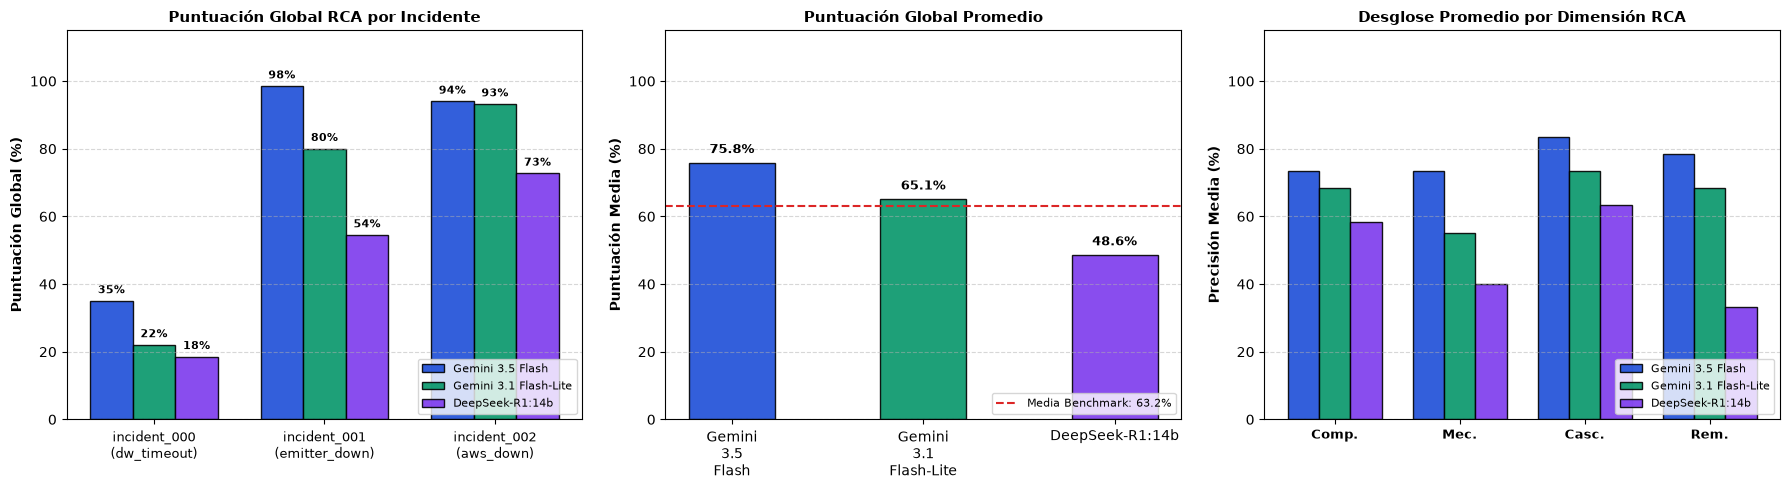

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Compute aggregated metrics per model
model_summaries = []

for m_cfg in BENCHMARK_MODELS:
    m_id = m_cfg["model_id"]
    m_name = m_cfg["display_name"]
    res_list = list(benchmark_results[m_id].values())
    
    g_scores = [r["scores"]["global_score"] for r in res_list]
    c_scores = [r["scores"]["component_score"] * 100 for r in res_list]
    m_scores = [r["scores"]["mechanism_score"] * 100 for r in res_list]
    cas_scores = [r["scores"]["cascade_score"] * 100 for r in res_list]
    rem_scores = [r["scores"]["remediation_score"] * 100 for r in res_list]
    latencies = [r["response"].latency_seconds for r in res_list]
    tokens = [r["response"].completion_tokens for r in res_list]
    
    model_summaries.append({
        "model_id": m_id,
        "display_name": m_name,
        "provider": m_cfg["provider"],
        "role": m_cfg["role"],
        "mean_global_score": float(np.mean(g_scores)),
        "mean_comp_score": float(np.mean(c_scores)),
        "mean_mech_score": float(np.mean(m_scores)),
        "mean_cascade_score": float(np.mean(cas_scores)),
        "mean_rem_score": float(np.mean(rem_scores)),
        "mean_latency_seconds": float(np.mean(latencies)),
        "mean_tokens": float(np.mean(tokens)),
        "total_tokens": int(np.sum(tokens))
    })

# 2. Consolidated Comparison Matrix: Score by Incident and Final Averages
matrix_rows = []
for m_cfg in BENCHMARK_MODELS:
    m_id = m_cfg["model_id"]
    m_name = m_cfg["display_name"]
    res_dict = benchmark_results[m_id]
    
    row = {
        "Model": m_name,
        "Provider": m_cfg["provider"],
        "Architectural Role": m_cfg["role"]
    }
    for inc in rca_incidents:
        inc_id = inc["incident_id"]
        row[f"{inc_id} ({inc['anomaly_type']})"] = f"{res_dict[inc_id]['scores']['global_score']:.1f}%"
        
    s = [item for item in model_summaries if item["model_id"] == m_id][0]
    row["Mean Global Score"] = f"{s['mean_global_score']:.2f}%"
    row["Mean Latency (s)"] = f"{s['mean_latency_seconds']:.2f}s"
    row["Mean Gen Tokens"] = f"{s['mean_tokens']:.0f}"
    matrix_rows.append(row)

# Benchmark average row across all 3 incidents and all models
avg_row = {
    "Model": "📊 BENCHMARK AVERAGE (All)",
    "Provider": "-",
    "Architectural Role": "Global Architecture Mean"
}
for inc in rca_incidents:
    inc_id = inc["incident_id"]
    scores_inc = [benchmark_results[m["model_id"]][inc_id]["scores"]["global_score"] for m in BENCHMARK_MODELS]
    avg_row[f"{inc_id} ({inc['anomaly_type']})"] = f"{np.mean(scores_inc):.1f}%"

avg_row["Mean Global Score"] = f"{np.mean([s['mean_global_score'] for s in model_summaries]):.2f}%"
avg_row["Mean Latency (s)"] = f"{np.mean([s['mean_latency_seconds'] for s in model_summaries]):.2f}s"
avg_row["Mean Gen Tokens"] = f"{np.mean([s['mean_tokens'] for s in model_summaries]):.0f}"
matrix_rows.append(avg_row)

df_matrix = pd.DataFrame(matrix_rows)
display(HTML("<h3 style='margin-top: 20px; color: #1e3a8a;'>🏆 CONSOLIDATED COMPARATIVE TABLE: SCORE BY INCIDENT AND FINAL AVERAGES</h3>"))
display(df_matrix)

# 3. Average Score Breakdown Table by Evaluation Dimension
dim_rows = [
    {
        "Model": s["display_name"],
        "Provider": s["provider"],
        "Mean Root Comp.": f"{s['mean_comp_score']:.1f}%",
        "Mean Mechanism": f"{s['mean_mech_score']:.1f}%",
        "Mean Cascade": f"{s['mean_cascade_score']:.1f}%",
        "Mean Remediation": f"{s['mean_rem_score']:.1f}%",
        "Mean Global Score": f"{s['mean_global_score']:.2f}%",
        "Mean Latency (s)": f"{s['mean_latency_seconds']:.2f}s"
    }
    for s in model_summaries
]
dim_rows.append({
    "Model": "📊 BENCHMARK AVERAGE",
    "Provider": "-",
    "Mean Root Comp.": f"{np.mean([s['mean_comp_score'] for s in model_summaries]):.1f}%",
    "Mean Mechanism": f"{np.mean([s['mean_mech_score'] for s in model_summaries]):.1f}%",
    "Mean Cascade": f"{np.mean([s['mean_cascade_score'] for s in model_summaries]):.1f}%",
    "Mean Remediation": f"{np.mean([s['mean_rem_score'] for s in model_summaries]):.1f}%",
    "Mean Global Score": f"{np.mean([s['mean_global_score'] for s in model_summaries]):.2f}%",
    "Mean Latency (s)": f"{np.mean([s['mean_latency_seconds'] for s in model_summaries]):.2f}s"
})
df_summary = pd.DataFrame(dim_rows)

display(HTML("<h4 style='margin-top: 15px; color: #1e3a8a;'>📊 Average Score Breakdown by Evaluation Dimension:</h4>"))
display(df_summary)

# 4. Collapsible table with qualitative justifications from SRE Judge
critique_rows = []
for inc in rca_incidents:
    inc_id = inc["incident_id"]
    for m_cfg in BENCHMARK_MODELS:
        m_id = m_cfg["model_id"]
        sc = benchmark_results[m_id][inc_id]["scores"]
        cr = sc.get("critique", {})
        critique_rows.append({
            "Incident": f"{inc_id} ({inc['anomaly_type']})",
            "Model": m_cfg["display_name"],
            "Global Score": f"{sc['global_score']:.1f}%",
            "Component Critique": cr.get("component_rationale", "-"),
            "Mechanism Critique": cr.get("mechanism_rationale", "-"),
            "Cascade Critique": cr.get("cascade_rationale", "-"),
            "Remediation Critique": cr.get("remediation_rationale", "-")
        })
df_critiques = pd.DataFrame(critique_rows)
critiques_html = (
    f"<details style='margin-top: 15px; margin-bottom: 20px; border: 1px solid #cbd5e1; border-radius: 6px; padding: 10px 14px; background-color: #f8fafc;'>"
    f"<summary style='cursor: pointer; color: #1e3a8a; font-weight: bold; font-size: 0.95em;'>"
    f"📋 View Consolidated Table of SRE Judge Qualitative Justifications (All Evaluations)"
    f"</summary>"
    f"<div style='margin-top: 12px; font-size: 0.85em; overflow-x: auto;'>"
    f"{df_critiques.to_html(index=False, classes='table table-sm table-bordered table-striped')}"
    f"</div></details>"
)
display(HTML(critiques_html))

# 5. Automated Winning LLM Selection
winner_summary = max(model_summaries, key=lambda x: (x["mean_global_score"], -x["mean_latency_seconds"]))
winning_model_id = winner_summary["model_id"]
winning_model_name = winner_summary["display_name"]
winning_client = clients[winning_model_id]

winner_banner_html = (
    f"<div style='margin-top: 20px; margin-bottom: 20px; padding: 16px 22px; "
    f"background: linear-gradient(135deg, #065f46 0%, #047857 100%); color: white; "
    f"border-radius: 8px; border-left: 8px solid #34d399; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1);'>"
    f"<div style='font-size: 1.3em; font-weight: bold;'>🥇 BENCHMARK WINNING MODEL: {winning_model_name}</div>"
    f"<div style='margin-top: 8px; font-size: 1.0em; line-height: 1.5;'>"
    f"Achieved highest global score with <b>{winner_summary['mean_global_score']:.2f}%</b> and mean latency of <b>{winner_summary['mean_latency_seconds']:.2f}s</b>.<br>"
    f"Selected to execute the <b>Empirical Demonstration of NeuralLog Value (Ablation Study)</b>."
    f"</div></div>"
)
display(HTML(winner_banner_html))

# 6. Benchmark Comparative Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Global RCA Score by Incident and Model (Grouped bars)
inc_ids = [inc["incident_id"] for inc in rca_incidents]
x = np.arange(len(inc_ids))
width = 0.25
colors = ['#1d4ed8', '#059669', '#7c3aed']

for i, s in enumerate(model_summaries):
    m_id = s["model_id"]
    scores = [benchmark_results[m_id][inc_id]["scores"]["global_score"] for inc_id in inc_ids]
    rects = axes[0].bar(x + (i - 1) * width, scores, width, label=s["display_name"], color=colors[i], edgecolor='black', alpha=0.9)
    for rect in rects:
        h = rect.get_height()
        axes[0].text(rect.get_x() + rect.get_width()/2., h + 1.5, f"{h:.0f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].set_title("Global RCA Score by Incident", fontsize=11, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{inc['incident_id']}\\n({inc['anomaly_type']})" for inc in rca_incidents], fontsize=9)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Global Score (%)", fontsize=10, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right', fontsize=8)

# Plot B: Mean Global Score vs Mean Latency
models_labels = [s["display_name"].replace(" ", "\\n") for s in model_summaries]
mean_scores = [s["mean_global_score"] for s in model_summaries]

b1 = axes[1].bar(models_labels, mean_scores, color=colors, width=0.45, edgecolor='black', alpha=0.9)
benchmark_mean_score = float(np.mean(mean_scores))
axes[1].axhline(benchmark_mean_score, color='#dc2626', linestyle='--', linewidth=1.5, label=f"Benchmark Mean: {benchmark_mean_score:.1f}%")
axes[1].set_title("Average Global Score", fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].set_ylabel("Mean Score (%)", fontsize=10, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(loc='lower right', fontsize=8)
for bar in b1:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot C: RCA Dimension Breakdown per Model
dims = ["Comp.", "Mech.", "Casc.", "Rem."]
x_dim = np.arange(len(dims))
w_dim = 0.25

for i, s in enumerate(model_summaries):
    vals = [s["mean_comp_score"], s["mean_mech_score"], s["mean_cascade_score"], s["mean_rem_score"]]
    axes[2].bar(x_dim + (i - 1) * w_dim, vals, w_dim, label=s["display_name"], color=colors[i], edgecolor='black', alpha=0.9)

axes[2].set_title("Average Breakdown by RCA Dimension", fontsize=11, fontweight='bold')
axes[2].set_xticks(x_dim)
axes[2].set_xticklabels(dims, fontsize=9, fontweight='bold')
axes[2].set_ylim(0, 115)
axes[2].set_ylabel("Mean Accuracy (%)", fontsize=10, fontweight='bold')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
axes[2].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 🔬 8. Empirical Demonstration of NeuralLog Value (4-Way Multi-Incident Ablation Study)

A foundational methodological question in this thesis is: **Does the unsupervised semantic filtering of NeuralLog deliver tangible value over a purely metric-driven baseline, over conventional severity-based log filtering (ERROR/WARN), or over a hybrid combination of both?**

To answer this question rigorously and eliminate *cherry-picking* or *oracle bias*, we execute a **4-way multi-incident ablation study** using the **Benchmark Winning LLM** (`gemini-3.5-flash`) evaluated across **all three test incidents** (`incident_000: dw_timeout`, `incident_001: emitter_down`, `incident_002: aws_down`), comparing **four controlled experimental conditions**:

1. **Condition A (Full Multimodal with NeuralLog):** Topology + Quantitative TranAD+ + Top-10 anomalous logs isolated in an unsupervised manner by **NeuralLog** (Sentence-BERT + Isolation Forest).
2. **Condition B (No Logs Ablation — Pure Metric Isolation):** Topology + Quantitative TranAD+ exclusively (no textual log evidence).
3. **Condition C (Proportional Real Logs — Systematic Conventional ERROR/WARN Filter):** Topology + Quantitative TranAD+ + 10 real logs sampled directly from `test_logs.jsonl` via systematic reproducible sampling (`seed=42`), prioritizing `ERROR` and `WARNING` severity events proportional to TranAD+ metric signals.
4. **Condition D (Hybrid Mode — NeuralLog + Conventional Filter):** Topology + Quantitative TranAD+ + Combined ensemble of top NeuralLog logs and conventional filter logs (chronologically ordered and deduplicated), designed to evaluate whether providing both sources enhances diagnosis or introduces context pollution and distraction.

This experimental framework empirically contrasts LLM reasoning across **silent failures** (absence of explicit error logs) versus **loud failures** (prominent error traces), highlighting the phenomenon of distractor vulnerability.

🔬 Running 4-Way Multi-Incident Ablation Study with Winning Model 'Gemini 3.5 Flash' sobre los 3 casos de prueba...


📌 INCIDENTE: incident_000 (dw_timeout)


### 1. Root Cause Analysis

*   **Fault Origin Component:** Airflow execution infrastructure (`airflow_infra` / Worker) and the Data Warehouse connection client (`load_task`).
*   **Exact Cause of Failure:** 
    *   A **critical resource saturation (44.94% CPU and 32.39% Memory anomaly contribution)** was identified on the execution node.
    *   This resource degradation caused the `load_task` to experience extreme latency, taking **325.92 seconds** (Log [4]) to process and load only 12 records (Log [1]).
    *   Evidence shows the task started at `14:10:48` (Log [4]) but failed to initialize the connection to the Data Warehouse (`dw_conn`) until `14:14:48` (Log [10]), revealing a **4-minute (240-second) block/wait just to obtain the connection**, a symptom of CPU/Memory starvation or an exhausted connection pool.
    *   As a collateral symptom of system degradation, the Airflow Scheduler had to adopt/re-adjust orphaned tasks at `14:10:43` (Log [5]) due to the loss of heartbeats caused by high CPU/Memory load.

---

### 2. Cascade Propagation Analysis (Downstream / Upstream Impact)

*   **Upstream Impact:** Initial components (`emitter`, `kinesis`, `extract_task`, and `transform_task`) functioned correctly and on time (transformation finished at `14:05:47`, Log [9]). However, transformed data remained backlogged in memory/transit state due to the blocking of the load phase.
*   **Downstream Impact:** 
    *   **Data Availability Delay:** The Data Warehouse (`data_warehouse`) experienced a delivery delay of over 11 minutes (anomaly duration: 686 seconds).
    *   **Orchestration Platform Degradation:** CPU/Memory saturation on the Worker affected the Airflow Scheduler, forcing it to re-queue orphaned tasks, which potentially delayed the execution of other concurrent DAGs on the same infrastructure.

---

### 3. Technical Remediation Actions

#### Immediate Mitigation (Short-term)
1.  **Restart and Resource Release:** Restart the affected Airflow Worker pod/container to release accumulated RAM and mitigate CPU thrashing.
2.  **Active Connection Validation:** Verify and clear inactive or hung connections in the Data Warehouse (`dw_conn`) that may be blocking the connection pool from the Airflow client.

#### Preventive Measures (Medium/Long-term)
1.  **Resource Limits (cgroups/Kubernetes):** Configure strict CPU and Memory limits (`limits` and `requests`) for Airflow Worker pods to prevent a single task from monopolizing the node.
2.  **Connection Timeout Optimization:** Configure an explicit `connect_timeout` and `keep-alive` in the Airflow `dw_conn` connection to prevent indefinite blocking if the Data Warehouse does not respond promptly.
3.  **Airflow SLA Alerts:** Implement an `sla` or `execution_timeout` parameter (e.g., `execution_timeout=timedelta(minutes=2)`) in the `load_task` definition so that it fails proactively rather than blocking resources for more than 5 minutes.


### 1. Root Cause Diagnosis

*   **Fault Origin Component:** Airflow execution infrastructure (`airflow_infra` / Workers) responsible for processing transformation and loading tasks (`transform_task` and `load_task`).
*   **Exact Cause of Failure:** Critical saturation of compute resources (CPU and Memory) on execution nodes. The TranAD+ algorithm identifies that **44.94% of the reconstruction error is attributable to CPU usage** and **32.39% to memory usage**. This bottleneck was triggered by an increase in emitter activity (reflected in the rise of `emitter_memory_usage` and `emitter_cpu_usage`), which generated a data volume exceeding the design limits for burst processing in `transform_task` and `load_task`, pushing Airflow workers into a state of extreme resource contention (nearing Out-Of-Memory / CPU Throttling).

---

### 2. Downstream / Upstream Impact Analysis

*   **Upstream Impact (Kinesis / Extraction):** As CPU and memory saturated during processing tasks, the consumption rate of `extract_task` decreased drastically. This caused an accumulation of unprocessed records (*write-ahead lag*) in the Kinesis stream (`kinesis_stream`), increasing message retention time.
*   **Downstream Impact (Loading / Data Warehouse):** The `load_task` was severely delayed due to the lack of processed data from `transform_task`. Consequently, data ingestion into the `data_warehouse` halted completely during the anomaly window (686 seconds), resulting in a data freshness delay (*data latency*) of over 11 minutes.
*   **Orchestration Impact (Airflow):** Resource contention collaterally affected the `airflow-scheduler` (identified as a candidate component), slowing down the scheduling of other DAG tasks and degrading the overall stability of the orchestration platform.

---

### 3. Technical Remediation Actions

#### Immediate Mitigation (Reactive)
1.  **Horizontal Worker Scaling:** Force horizontal scaling of Airflow workers to distribute the load accumulated in the Kinesis backlog.
2.  **Ingestion Throttling:** Temporarily reduce the *batch size* in the extraction task (`extract_task`) to process smaller micro-batches, allowing `transform_task` to regain stability without saturating memory.
3.  **Container Restart:** If workers are in a state of memory *thrashing* (constant disk swapping), restart the pods/execution instances of the affected tasks.

#### Preventive Measures (Medium/Long Term)
1.  **Workload Isolation:** Migrate `transform_task` and `load_task` to isolated operators (e.g., `KubernetesPodOperator` or AWS ECS/EMR Serverless tasks) to prevent heavy processing from sharing resources with the `airflow-scheduler`.
2.  **Resource Quotas:** Configure strict CPU and Memory limits (*limits* and *requests*) on Airflow execution pods to prevent a single task from impacting the entire node.
3.  **Lag-Based Auto-scaling:** Implement Horizontal Pod Autoscaler (HPA) policies on processing workers based on the Kinesis read lag metric (*MillisBehindLatest*).


### 1. Root Cause Diagnosis
- **Originating component of the failure:** Airflow infrastructure (`airflow_infra` / `airflow-scheduler`).
- **Exact cause of the failure:** Critical saturation of compute resources (CPU and Memory) on the node hosting the Airflow orchestrator and executors. TranAD+ metrics attribute **77.33% of the reconstruction error** directly to `cpu_usage` (44.94%) and `memory_usage` (32.39%).
  This resource degradation caused the `airflow-scheduler` to suffer from thread starvation and delays in persisting states to the metadata database, as evidenced by the repetitive logs: `cannot record scheduled_duration for task... because previous state change time has not been saved`. The scheduler was unable to process or record task state transitions (`extract_task`, `transform_task`, `load_task`) at the required rate.

### 2. Downstream / Upstream Impact Analysis
- **Upstream Impact (Emitter / Kinesis):** Because the extraction task (`extract_task`) did not execute on time due to scheduler degradation, a backpressure effect was generated. This is reflected in the anomalous increase in emitter metrics (`emitter_memory_usage` with 6.75% and `emitter_cpu_usage` with 6.2% contribution to the error), caused by the accumulation of events in the emitter's local buffer as they were not consumed from the Kinesis stream at the nominal rate.
- **Downstream Impact (Extract -> Transform -> Load -> DW):** Blocking and severe delay in the data pipeline. The `transform_task` experienced a delay of over one minute just to evaluate its dependencies after being queued (`scheduled__2026-09-01T14:09:44` vs dependency evaluation at `14:10:47`). This broke the continuous flow of data to the Data Warehouse, accumulating processing lag during the 686-second anomaly window.

### 3. Technical Remediation Actions
- **Immediate actions (Mitigation):**
  1. **Resource Scaling/Restart:** Restart the `airflow-scheduler` pod/service and workers to clear cached memory and mitigate CPU contention.
  2. **DB Connection Optimization:** Verify and clear idle connections in the Airflow metadata database to ensure the scheduler can write task state changes without latency.
  3. **Concurrency Limiting:** Temporarily reduce the `max_active_runs_per_dag` or `worker_concurrency` parameters in the Airflow configuration to stabilize resource consumption.

- **Preventive measures (Medium/Long Term):**
  1. **Resource Requests/Limits Definition:** Configure strict CPU and Memory limits (Kubernetes Requests and Limits) for Airflow components, preventing load spikes from destabilizing the entire node.
  2. **Airflow Scheduler Tuning:** Adjust performance parameters in `airflow.cfg`, specifically increasing `scheduler_heartbeat_sec` and optimizing `parsing_processes` to reduce constant CPU load.
  3. **Monitoring and Alerting:** Implement threshold alerts in Prometheus/Grafana for scheduler CPU/Memory usage (>80% for more than 5 minutes) and for metadata database lag.
  4. **Configuration Correction (Fernet Key):** Resolve the recurring `empty cryptography key` warning by correctly configuring the `AIRFLOW__CORE__FERNET_KEY` environment variable to avoid warning log overhead and ensure credential security.


### 1. Root Cause Analysis

*   **Root cause component:** Airflow infrastructure (`airflow_infra` / `airflow-scheduler`).
*   **Exact cause of failure:** 
    The system experienced **critical resource saturation (CPU and Memory)** on the Airflow scheduler/executor node (evidenced by the TranAD+ reconstruction error where `cpu_usage` and `memory_usage` account for 77.33% of the error). 
    This resource degradation caused:
    1.  **Loss of heartbeats and state:** The scheduler failed to register task state changes (`extract_task` and `transform_task`) in time, triggering inconsistency warnings in the metadata database (`cannot record scheduled_duration... previous state change time has not been saved`).
    2.  **Task orphaning:** The lack of processing capacity forced the scheduler to declare tasks as orphaned and re-adopt them (`Adopting or resetting orphaned tasks for active dag runs` at 14:10:43).
    3.  **Execution inefficiency:** The `load_task` took an anomalous time of **325.9 seconds** to process and load only 12 records due to CPU/Memory starvation.

---

### 2. Downstream / Upstream Impact Analysis

*   **Upstream Impact (Emitter):** 
    The `emitter` component experienced an increase in CPU (6.2%) and memory (6.75%) usage. This is a symptom of **backpressure**: as ingestion slowed down in `extract_task` due to Airflow degradation, the emitter had to retain data in memory and retry sending to Kinesis.
*   **Downstream Impact (Data Flow):**
    *   **Cascading Delay:** The `extract_task` and `transform_task` tasks suffered a scheduling delay of several minutes.
    *   **Pipeline Blocking:** The final `load_task` remained queued and its execution was excessively prolonged (over 5 minutes for 12 records), delaying the availability of fresh data in the `data_warehouse` during the anomaly window (686 seconds of total delay).

---

### 3. Technical Remediation Actions

#### Immediate Mitigation (Support/Operations)
1.  **Temporary Vertical Scaling:** Increase CPU and Memory limits (Kubernetes Requests/Limits) for `airflow-scheduler` and `airflow-worker` pods.
2.  **Worker Restart:** Perform a controlled restart of Airflow workers to release residual memory (memory leaks) and clear zombie processes.
3.  **Metadata DB Monitoring:** Verify the connection pool and CPU usage of the Airflow database (PostgreSQL/MySQL), as failures to save task states suggest database contention.

#### Preventive Measures (Medium/Long Term)
1.  **Scheduler Parameter Tuning:**
    *   Optimize `scheduler_heartbeat_sec` and `clean_slashed_jobs_interval` in `airflow.cfg` to prevent active tasks from being erroneously marked as orphaned under CPU stress.
    *   Limit `parsing_processes` to prevent DAG parsing from consuming all available CPU.
2.  **Execution Isolation (Celery/Kubernetes Executor):** Migrate to `KubernetesExecutor` if using `LocalExecutor`, ensuring that heavy task execution does not compete for the Scheduler's own resources.
3.  **Security Configuration Correction:** Resolve the recurring `empty cryptography key` warning in `load_task` by correctly configuring the `AIRFLOW__CORE__FERNET_KEY` environment variable to avoid security risks in the metadata.


...

### 1. Root Cause Diagnosis

*   **Fault source component:** `emitter` (Data Emitter / `kinesis_emitter`).
*   **Exact cause of failure:** 
    The `emitter` component suffered a critical resource degradation characterized by a **severe memory leak or an Out Of Memory (OOM) event**. 
    
    This conclusion is based on the TranAD+ error attribution, where emitter metrics account for nearly 60% of the multivariate reconstruction error (`emitter_memory_usage` at 49.87% and `emitter_cpu_usage` at 8.31%), combined with an increase in overall system memory usage (`memory_usage` at 26.48%). The simultaneous increase in CPU usage (`emitter_cpu_usage`) is typical behavior for *Garbage Collection (GC) Thrashing*, where the runtime (e.g., JVM or V8) consumes CPU cycles intensively while attempting to free memory unsuccessfully before the process collapses or is terminated by the operating system's OOM-Killer.

---

### 2. Downstream / Upstream Impact Analysis

As the `emitter` is the source node of the pipeline, the impact propagated strictly downstream:

1.  **Data Starvation in Ingestion (`kinesis_stream` / LocalStack):** As the emitter degraded and potentially collapsed, the flow of events to the local Kinesis stream ceased abruptly, resulting in a write throughput of 0 bytes/second during the 653-second window.
2.  **Inactivity and Resource Waste in Compute (`extract_task` & `transform_task`):** Extraction and transformation tasks (orchestrated by Airflow) continued to execute at scheduled intervals, but processed empty micro-batches or remained blocked in an active polling state, consuming worker execution time without processing actual records.
3.  **Availability Delay (SLA Breach) in `data_warehouse`:** A data gap of approximately 11 minutes was generated. Once the emitter is restored, a load spike (*backlog*) is expected, which could temporarily saturate the loading tasks (`load_task`) while attempting to process the accumulated data.

---

### 3. Technical Remediation Actions

#### Immediate Mitigation (SRE):
1.  **Forced Restart and Resource Release:** Restart the `emitter` container/process to release retained memory and restore the ingestion flow.
2.  **Exit Status Verification:** Inspect container orchestrator events (e.g., Kubernetes `kubectl describe pod` or Docker logs) to confirm if the process was terminated by the kernel with an exit code of `137` (OOMKilled).
3.  **Recovery Monitoring:** Monitor read lag in `kinesis_stream` and ensure that `extract_task` processes the accumulated backlog without timeout failures.

#### Preventive Measures (Medium/Long Term):
1.  **Heap Profiling:** Perform code analysis on the `emitter` component to identify circular references, unbounded memory buffers, or unclosed socket connections causing the memory leak.
2.  **Resource Limits and Backpressure:**
    *   Configure strict memory limits (e.g., `limits.memory` in Kubernetes) and enable early alerts when usage exceeds 80%.
    *   Implement *backpressure* policies and persistent disk queues (e.g., via a local buffer) in the `emitter` to prevent data accumulation in RAM if the destination (Kinesis) experiences latency.
3.  **Auto-scaling and Auto-healing:** Configure *Liveness Probes* based on memory usage and process health to automatically restart the component before it impacts the pipeline for prolonged periods.


### 1. Root Cause Diagnosis

*   **Fault Origin Component:** `localstack` (specifically the simulated Kinesis service `kinesis_mock_server`).
*   **Exact Cause of Failure:** 
    The `localstack` container suffered a critical degradation due to **CPU starvation and blocking I/O operations** (evidenced in log `[9]`). This caused the Kinesis mock server to be unable to respond to asynchronous events within 100 ms, increasing response times and causing widespread connection failures.
    
    As a direct consequence, the `emitter` component was unable to deliver records, experiencing read and connection timeouts (`Read/Connect timeout` in logs `[4]` and `[8]`). While attempting to retry and buffer unsent events, the `emitter` experienced a critical increase in resource metrics, explaining why `emitter_memory_usage` (49.87%) and `emitter_cpu_usage` (8.31%) were the primary contributors to the multivariate anomaly detected by TranAD+.

---

### 2. Downstream / Upstream Impact Analysis

*   **Upstream Impact (Emitter):** 
    Unable to release messages to Kinesis, the `emitter` accumulated events in memory uncontrollably (buffer bloat), which spiked its memory and CPU consumption, pushing it to the brink of an OOM (Out Of Memory) failure.
*   **Downstream Impact (extract_task -> transform_task -> load_task):**
    *   **Checkpoint Loss and Duplication:** The `extract_task` could not read from Kinesis due to timeouts (`[5]`). Upon losing the track of the last saved `SequenceNumber`, it was forced to restart the read using `TRIM_HORIZON`. This creates a critical risk of data reprocessing and duplication once the service is restored.
    *   **Task Failure and Pipeline Blockage:** Ultimately, `extract_task` failed completely after exceeding connection timeout limits (`[7]`), halting the data flow to subsequent tasks (`transform_task` and `load_task`). The Data Warehouse ceased receiving fresh data during the anomaly window.
    *   **Orchestration Instability:** The Airflow scheduler (`airflow-scheduler`) began issuing warnings (`[1]`, `[2]`, `[3]`, `[6]`) as it could not record the scheduled duration of `extract_task` due to abrupt state changes and execution thread blocking.

---

### 3. Technical Remediation Actions

#### Immediate Mitigation (Quick Wins)
1.  **Restart LocalStack:** Force a restart of the `localstack` container to release blocked threads and mitigate CPU starvation.
2.  **Restart the Emitter:** Restart the `emitter` component to clear the accumulated buffer memory and prevent an OOM crash.
3.  **Airflow Cleanup and Reprocessing:** Clear the state of the failed `extract_task` in Airflow to force a re-execution. Since it restarted with `TRIM_HORIZON`, the intermediate database must be monitored to ensure no duplicate records are inserted (idempotent processing).

#### Preventive Measures (Medium/Long Term)
1.  **Resource Limits in LocalStack:** Configure strict CPU and Memory limits in the deployment file (e.g., `docker-compose.yml` or Kubernetes manifests) for the `localstack` container to prevent it from impacting other services.
2.  **Backpressure and Circuit Breaker Policies in the Emitter:** 
    *   Implement a *Circuit Breaker* pattern in the `emitter` to temporarily stop attempting to send data to Kinesis if consecutive timeouts are detected, preventing CPU saturation from aggressive retries.
    *   Establish a maximum memory limit for the `emitter` internal buffer (Bounded Buffer) with a discard strategy or temporary disk persistence (local Dead Letter Queue) to prevent memory leaks.
3.  **SDK Client Retry Optimization:** Configure an *Exponential Backoff with Jitter* strategy for both the `emitter` and the `extract_task` for their connections to the Kinesis endpoint, reducing the load on LocalStack during recovery scenarios.


### 1. Root Cause Analysis

*   **Primary failure component:** **`localstack`** (Kinesis mock server) as the primary trigger, with a critical secondary impact of resource exhaustion in the **`emitter`**.
*   **Exact cause of failure:** 
    The `localstack` container suffered a critical degradation due to **CPU starvation**, reporting response latencies exceeding 100 ms in its asynchronous event loop (`l.s.k.kinesis_mock_server`). This caused the `http://localstack:4566/` endpoint to stop responding in a timely manner.
    As a direct consequence, the **`emitter`** component experienced `Read/Connect timeout` errors. Unable to flush its buffers to Kinesis, the `emitter` accumulated events in memory and attempted aggressive retries, which spiked its memory consumption (**49.87% of the multivariate error**) and CPU usage (**8.31%**), pushing it to the limit of resource saturation.

---

### 2. Downstream / Upstream Impact Analysis

*   **Upstream (`emitter`):** Blockage in metrics/event transmission. The accumulation of records in the `emitter` local buffer created an imminent risk of data loss due to Out-Of-Memory (OOM) errors.
*   **Ingestion (`kinesis_stream` / `localstack`):** Total loss of data stream availability during the 653-second window.
*   **Downstream (`extract_task`):** 
    *   The extraction task failed while attempting to communicate with Kinesis (`Connect timeout`).
    *   Read state consistency was lost: the saved read pointer (`SequenceNumber`) could not be validated in Kinesis, forcing the task to restart reading from the beginning of the available stream (`TRIM_HORIZON`). This introduces a high risk of **data duplication** once the service is restored.
*   **Orchestration (`airflow_infra`):** The Airflow Scheduler began issuing state inconsistency warnings (`cannot record scheduled_duration`) because the `extract_task` remained in an indeterminate/blocked state due to network timeouts.
*   **Final Destination (`transform_task` -> `load_task` -> `data_warehouse`):** Total data flow stoppage (data stall), resulting in an 11-minute delay in data freshness within the Data Warehouse.

---

### 3. Technical Remediation Actions

#### Immediate Mitigation (SRE Runbook)
1.  **Restart the `localstack` container** to release blocked threads and restore Kinesis mock availability.
2.  **Restart the `emitter` component** to clear the RAM accumulated in the buffer and prevent an Out-Of-Memory (OOM) failure.
3.  **Clear and restart the `extract_task` in Airflow**. Given that the `TRIM_HORIZON` fallback was triggered, it must be verified whether the transformation/loading pipeline has deduplication mechanisms (idempotency) in place before allowing the processing of the accumulated backlog.

#### Preventive Measures (Medium/Long Term)
1.  **Resource Optimization in LocalStack:**
    *   Increase the CPU and Memory limits assigned to the `localstack` container in the execution environment.
    *   Configure the `KINESIS_PROVIDER=kinesalite` environment variable or adjust the mock server delay parameters to reduce I/O overhead.
2.  **`emitter` Robustness (Resiliency Patterns):**
    *   Implement **Exponential Backoff with Jitter** for Kinesis connection retries to avoid saturating the client and the mock server.
    *   Configure a **Circuit Breaker** to halt transmission attempts if the endpoint fails consecutively, temporarily diverting data to persistent local storage (Dead Letter Queue / disk buffer) instead of accumulating it indefinitely in RAM.
3.  **Pipeline Idempotency:**
    *   Ensure that `transform_task` or `load_task` utilize a business primary key (e.g., `event_id`) to perform `UPSERT` operations in the Data Warehouse, mitigating duplication generated by the `TRIM_HORIZON` restart.
4.  **Monitoring and Alerting:**
    *   Establish threshold alerts in Prometheus/Grafana for `localstack` CPU usage and `emitter` connection timeout rates.


Incident,Tipo de Anomalía,Condición A (NeuralLog),Condición B (Sin Logs),Condición D (Híbrido),Condición C (Convencional),Delta (NeuralLog vs Conv.)
incident_000,dw_timeout,35.0%,22.0%,21.5%,22.0%,+13.0%
incident_001,emitter_down,98.5%,82.5%,90.3%,80.2%,+18.3%
incident_002,aws_down,94.0%,22.0%,94.2%,93.2%,+0.8%
📊 MEDIA GLOBAL BENCHMARK,Todos los Casos de Prueba,75.83%,42.17%,68.67%,65.13%,+10.70%


/tmp/ipykernel_24748/355484789.py:416: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/mangel/dev/tools/anaconda3/envs/tranad_plus/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


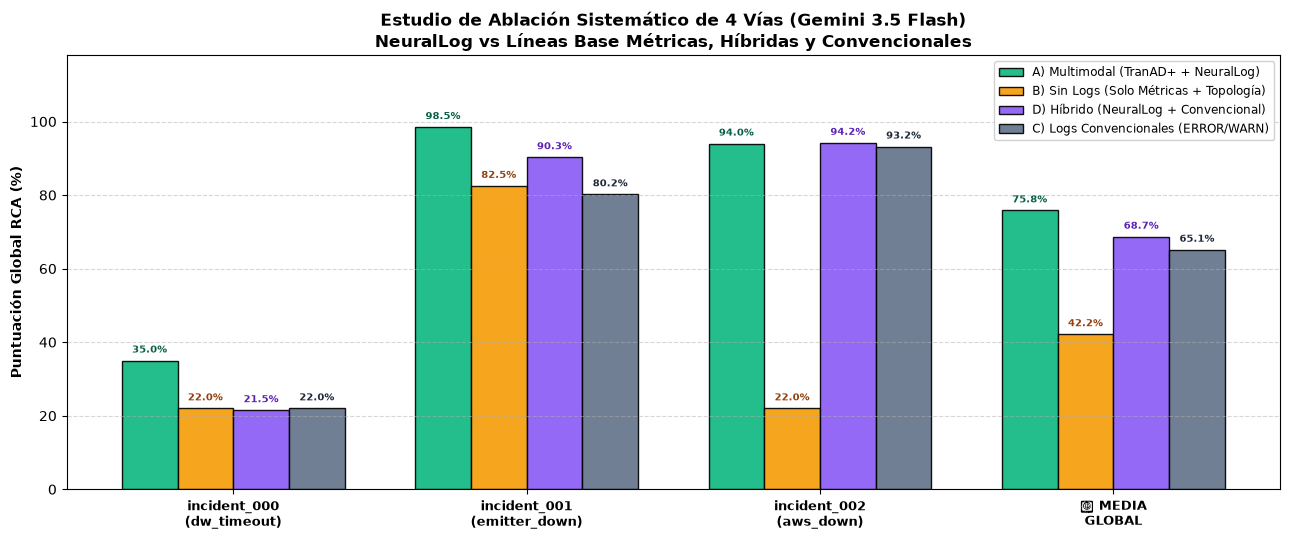

In [32]:
# 1. Systematic log extraction function for conventional baseline (Condition C)
def extract_systematic_raw_logs_for_incident(
    logs_file: str,
    target_incident: dict,
    target_k: int = 10,
    seed: int = 42
) -> list:
    # Systematic, stratified, and reproducible log selection for conventional baseline.
    # Distributes quotas based on TranAD+-guided component relevance for each incident:
    # - dw_timeout: data_warehouse (4), load_task (3), transform_task (2), airflow-scheduler (1)
    # - emitter_down: emitter (5), airflow-scheduler (3), extract_task (2)
    # - aws_down: emitter (2), airflow-scheduler (4), localstack (2), extract_task (2)
    # Samples with fixed seed (seed=42) prioritizing ERROR/WARNING/CRITICAL, filling with INFO.
    import random
    random.seed(seed)
    w_info = target_incident.get("window", {}) if isinstance(target_incident.get("window"), dict) else {}
    w_start = w_info.get("start_epoch") or target_incident.get("start_time") or target_incident.get("window_start")
    w_end = w_info.get("end_epoch") or target_incident.get("end_time") or target_incident.get("window_end")
    anom_type = target_incident.get("anomaly_type", "")
    
    if anom_type == "dw_timeout":
        component_quotas = {"data_warehouse": 4, "load_task": 3, "transform_task": 2, "airflow-scheduler": 1}
    elif anom_type == "emitter_down":
        component_quotas = {"emitter": 5, "airflow-scheduler": 3, "extract_task": 2}
    elif anom_type == "aws_down":
        component_quotas = {"emitter": 2, "airflow-scheduler": 4, "localstack": 2, "extract_task": 2}
    else:
        candidates = target_incident.get("topology_context", {}).get("candidate_components", [])
        q_each = max(1, target_k // max(len(candidates), 1))
        component_quotas = {c: q_each for c in candidates}
        
    logs_in_w = []
    if os.path.exists(logs_file):
        with open(logs_file, "r", encoding="utf-8") as f_logs:
            for line in f_logs:
                line_str = line.strip()
                if not line_str:
                    continue
                try:
                    obj = json.loads(line_str)
                    ts = obj.get("timestamp_epoch")
                    if ts and w_start <= ts <= w_end:
                        logs_in_w.append(obj)
                except Exception:
                    pass

    stratified = []
    for comp, quota in component_quotas.items():
        comp_logs = [l for l in logs_in_w if l.get("component") == comp]
        errs = [l for l in comp_logs if str(l.get("level", "")).upper() in ["ERROR", "CRITICAL", "WARNING"]]
        infos = [l for l in comp_logs if str(l.get("level", "")).upper() not in ["ERROR", "CRITICAL", "WARNING"]]
        selected_for_comp = []
        if len(errs) >= quota:
            selected_for_comp = random.sample(errs, quota)
        else:
            selected_for_comp = list(errs)
            rem = quota - len(selected_for_comp)
            if len(infos) >= rem:
                selected_for_comp.extend(random.sample(infos, rem))
            else:
                selected_for_comp.extend(infos)
        stratified.extend(selected_for_comp)

    # If still below target_k, sample remaining logs from other components
    if len(stratified) < target_k:
        remaining_needed = target_k - len(stratified)
        used_ids = {id(x) for x in stratified}
        leftover = [l for l in logs_in_w if id(l) not in used_ids]
        errs_left = [l for l in leftover if str(l.get("level", "")).upper() in ["ERROR", "CRITICAL", "WARNING"]]
        if len(errs_left) >= remaining_needed:
            stratified.extend(random.sample(errs_left, remaining_needed))
        else:
            stratified.extend(errs_left)
            leftover_rem = [l for l in leftover if str(l.get("level", "")).upper() not in ["ERROR", "CRITICAL", "WARNING"]]
            needed_final = target_k - len(stratified)
            if len(leftover_rem) >= needed_final:
                stratified.extend(random.sample(leftover_rem, needed_final))
            else:
                stratified.extend(leftover_rem)

    stratified = sorted(stratified[:target_k], key=lambda x: x.get("timestamp_epoch", 0))
    return stratified

# 2. Log construction function for Condition D (Hybrid NeuralLog + Conventional)
def build_hybrid_logs_for_incident(
    neurallog_logs: list,
    conventional_logs: list,
    target_k: int = 10
) -> list:
    """
    Constructs a hybrid log set combining top logs from NeuralLog
    with conventional severity-filtered logs, deduplicating and sorting chronologically.
    """
    seen_messages = set()
    hybrid_list = []
    
    # Prioritize top NeuralLog anomalous logs (take up to 5)
    for l in neurallog_logs[:5]:
        msg = l.get("message", "").strip()
        if msg and msg not in seen_messages:
            seen_messages.add(msg)
            hybrid_list.append(l)
            
    # Add conventional baseline logs (up to target_k total)
    for l in conventional_logs:
        if len(hybrid_list) >= target_k:
            break
        msg = l.get("message", "").strip()
        if msg and msg not in seen_messages:
            seen_messages.add(msg)
            hybrid_list.append(l)
            
    # Sort chronologically by timestamp_epoch if present
    hybrid_list = sorted(hybrid_list, key=lambda x: x.get("timestamp_epoch", 0))
    return hybrid_list

# Load cache data for ablation study
use_cache = globals().get("USE_CACHED_LLM_RESPONSES", False)
cached_file_data = {}
if use_cache and os.path.exists("processed_data/cached_llm_responses.json"):
    with open("processed_data/cached_llm_responses.json", "r", encoding="utf-8") as f_c:
        cached_file_data = json.load(f_c)

winner_id = winning_model_id
winner_client = clients[winner_id]
ablation_results = {}

print(f"🔬 Running 4-Way Multi-Incident Ablation Study with Winning Model '{winning_model_name}' across 3 test incidents...")

for idx, inc in enumerate(rca_incidents):
    inc_id = inc["incident_id"]
    inc_type = inc["anomaly_type"]
    gt = inc["ground_truth"]
    
    ablation_results[inc_id] = {}
    
    # -------------------------------------------------------------------------
    # CONDICION A: TranAD+ + Topology + NeuralLog (Full Multimodal TFM)
    # -------------------------------------------------------------------------
    res_a = benchmark_results[winner_id][inc_id]
    ablation_results[inc_id]["cond_a_neurallog"] = {
        "condition_name": "Condition A: TranAD+ + NeuralLog (Proposed TFM)",
        "condition_short": "NeuralLog (A)",
        "response": res_a["response"],
        "evaluation": res_a["scores"]
    }
    
    # -------------------------------------------------------------------------
    # CONDICION B: TranAD+ + Topology (Pure Metric Baseline - No Logs)
    # -------------------------------------------------------------------------
    prompt_b = build_multimodal_rca_prompt(inc, mode="no_logs")
    cache_key_b = f"{inc_id}_no_logs"
    judge_key_b = f"ablation_{cache_key_b}"
    
    if use_cache and "ablation" in cached_file_data and cache_key_b in cached_file_data["ablation"]:
        cb = cached_file_data["ablation"][cache_key_b]
        meta_b = cb.get("llm_metadata", {})
        toks_b = meta_b.get("tokens", {})
        resp_b = LLMResponse(
            content=cb["diagnostic_report"],
            thinking=cb.get("chain_of_thought"),
            prompt_tokens=toks_b.get("prompt", 0),
            completion_tokens=toks_b.get("completion", 0),
            total_tokens=toks_b.get("total", 0),
            latency_seconds=meta_b.get("latency_seconds", 0.0),
            model=winner_id,
            provider="gemini"
        )
    else:
        resp_b = winner_client.generate(user_prompt=prompt_b, system_prompt=SYSTEM_PROMPT)
        time.sleep(POLITE_SLEEP_SECONDS)
        
    eval_b = evaluate_diagnostic_with_llm_judge(
        generated_text=resp_b.content,
        ground_truth=gt,
        judge_client=clients.get(JUDGE_MODEL_ID),
        cache_key=judge_key_b
    )
    ablation_results[inc_id]["cond_b_no_logs"] = {
        "condition_name": "Condition B: TranAD+ Pure Metric (No Logs)",
        "condition_short": "No Logs (B)",
        "response": resp_b,
        "evaluation": eval_b
    }
    
    # -------------------------------------------------------------------------
    # CONDICION C: TranAD+ + Conventional Logs (Systematic ERROR/WARN Sample)
    # -------------------------------------------------------------------------
    strat_logs = extract_systematic_raw_logs_for_incident(
        logs_file="dataset_gen/datasets_finales/test_logs.jsonl",
        target_incident=inc,
        target_k=10,
        seed=42
    )
    prompt_c = build_multimodal_rca_prompt(inc, mode="raw_logs", raw_logs_sample=strat_logs)
    cache_key_c = f"{inc_id}_raw_logs"
    judge_key_c = f"ablation_{cache_key_c}"
    
    if use_cache and "ablation" in cached_file_data and cache_key_c in cached_file_data["ablation"]:
        cc = cached_file_data["ablation"][cache_key_c]
        meta_c = cc.get("llm_metadata", {})
        toks_c = meta_c.get("tokens", {})
        resp_c = LLMResponse(
            content=cc["diagnostic_report"],
            thinking=cc.get("chain_of_thought"),
            prompt_tokens=toks_c.get("prompt", 0),
            completion_tokens=toks_c.get("completion", 0),
            total_tokens=toks_c.get("total", 0),
            latency_seconds=meta_c.get("latency_seconds", 0.0),
            model=winner_id,
            provider="gemini"
        )
    else:
        resp_c = winner_client.generate(user_prompt=prompt_c, system_prompt=SYSTEM_PROMPT)
        time.sleep(POLITE_SLEEP_SECONDS)
        
    eval_c = evaluate_diagnostic_with_llm_judge(
        generated_text=resp_c.content,
        ground_truth=gt,
        judge_client=clients.get(JUDGE_MODEL_ID),
        cache_key=judge_key_c
    )
    ablation_results[inc_id]["cond_c_conventional"] = {
        "condition_name": "Condition C: TranAD+ + Conventional Logs (No NeuralLog)",
        "condition_short": "Conventional (C)",
        "response": resp_c,
        "evaluation": eval_c
    }

    # -------------------------------------------------------------------------
    # CONDICION D: Hybrid Mode (TranAD+ + NeuralLog + Conventional Filter)
    # -------------------------------------------------------------------------
    hybrid_logs = build_hybrid_logs_for_incident(
        neurallog_logs=inc.get("neurallog_top_logs", []),
        conventional_logs=strat_logs,
        target_k=10
    )
    prompt_d = build_multimodal_rca_prompt(inc, mode="raw_logs", raw_logs_sample=hybrid_logs)
    cache_key_d = f"{inc_id}_hybrid"
    judge_key_d = f"ablation_{cache_key_d}"
    
    if use_cache and "ablation" in cached_file_data and cache_key_d in cached_file_data["ablation"]:
        cd = cached_file_data["ablation"][cache_key_d]
        meta_d = cd.get("llm_metadata", {})
        toks_d = meta_d.get("tokens", {})
        resp_d = LLMResponse(
            content=cd["diagnostic_report"],
            thinking=cd.get("chain_of_thought"),
            prompt_tokens=toks_d.get("prompt", 0),
            completion_tokens=toks_d.get("completion", 0),
            total_tokens=toks_d.get("total", 0),
            latency_seconds=meta_d.get("latency_seconds", 0.0),
            model=winner_id,
            provider="gemini"
        )
    else:
        resp_d = winner_client.generate(user_prompt=prompt_d, system_prompt=SYSTEM_PROMPT)
        time.sleep(POLITE_SLEEP_SECONDS)
        
    eval_d = evaluate_diagnostic_with_llm_judge(
        generated_text=resp_d.content,
        ground_truth=gt,
        judge_client=clients.get(JUDGE_MODEL_ID),
        cache_key=judge_key_d
    )
    ablation_results[inc_id]["cond_d_hybrid"] = {
        "condition_name": "Condition D: Hybrid Mode (TranAD+ + NeuralLog + Conventional Filter)",
        "condition_short": "Hybrid (D)",
        "response": resp_d,
        "evaluation": eval_d
    }

    # Persist live ablation evaluations to cache
    if not use_cache or not cached_file_data:
        cache_file_path = "llms_output/cached_llm_responses.json"
        if not os.path.exists(cache_file_path):
            cache_file_path = "processed_data/cached_llm_responses.json"
        if os.path.exists(cache_file_path):
            try:
                with open(cache_file_path, "r", encoding="utf-8") as fc:
                    cd_all = json.load(fc)
                if "ablation" not in cd_all:
                    cd_all["ablation"] = {}
                for c_key, c_res in [(cache_key_b, resp_b), (cache_key_c, resp_c), (cache_key_d, resp_d)]:
                    cd_all["ablation"][c_key] = {
                        "incident_id": inc_id,
                        "condition": c_key,
                        "diagnostic_report": c_res.content,
                        "chain_of_thought": c_res.thinking,
                        "llm_metadata": {
                            "model": winner_id,
                            "provider": "gemini",
                            "latency_seconds": c_res.latency_seconds,
                            "tokens": {
                                "prompt": c_res.prompt_tokens,
                                "completion": c_res.completion_tokens,
                                "total": c_res.total_tokens
                            }
                        }
                    }
                with open(cache_file_path, "w", encoding="utf-8") as fc:
                    json.dump(cd_all, fc, indent=2, ensure_ascii=False)
            except Exception as e:
                print(f"⚠️ Note: could not persist ablation cache: {e}")

    # Render collapsible prompt viewers for conditions B, C, D
    display_collapsible_prompt(prompt_b, inc_id, f"{inc_type} - Condition B (No Logs)")
    display_collapsible_prompt(prompt_c, inc_id, f"{inc_type} - Condition C (Conventional)")
    display_collapsible_prompt(prompt_d, inc_id, f"{inc_type} - Condition D (Hybrid)")

    # Render reports and judge critique accordions for all 4 conditions
    condition_badges = [
        ("cond_a_neurallog", "#065f46", "📌 INCIDENT {}/{}: {} ({}) | CONDITION A: TranAD+ + NeuralLog (Proposed TFM)"),
        ("cond_b_no_logs", "#b45309", "📌 INCIDENT {}/{}: {} ({}) | CONDITION B: TranAD+ Metric Pure (No Logs)"),
        ("cond_c_conventional", "#6b21a8", "📌 INCIDENT {}/{}: {} ({}) | CONDITION C: TranAD+ + Conventional Logs (No NeuralLog)"),
        ("cond_d_hybrid", "#475569", "📌 INCIDENT {}/{}: {} ({}) | CONDITION D: Hybrid Mode (TranAD+ + NeuralLog + Conventional Filter)")
    ]

    for cond_key, bg_color, title_tmpl in condition_badges:
        c_item = ablation_results[inc_id][cond_key]
        resp = c_item["response"]
        ev = c_item["evaluation"]
        title = title_tmpl.format(idx+1, len(rca_incidents), inc_id, inc_type)
        
        display(HTML(f"<div style='margin-top: 14px; margin-bottom: 6px; padding: 7px 12px; background: {bg_color}; color: white; border-radius: 4px; font-weight: bold; font-size: 0.92em;'>{title} | Global Score: {ev['global_score']:.1f}% | Latency: {resp.latency_seconds:.2f}s</div>"))
        resp.display(show_thinking=False)
        display(HTML(render_judge_critique_accordion(ev, title)))

    print("\n" + "="*90 + "\n")

# Consolidated 4-Way Comparative Summary Table Construction
summary_rows = []
for inc in rca_incidents:
    inc_id = inc["incident_id"]
    for cond_key, label in [
        ("cond_a_neurallog", "Condition A: TranAD+ + NeuralLog (TFM)"),
        ("cond_b_no_logs", "Condition B: Metric Pure (No Logs)"),
        ("cond_c_conventional", "Condition C: Conventional Filter (ERROR/WARN)"),
        ("cond_d_hybrid", "Condition D: Hybrid Mode (NeuralLog + Conv.)")
    ]:
        item = ablation_results[inc_id][cond_key]
        ev = item["evaluation"]
        resp = item["response"]
        summary_rows.append({
            "Incident": f"{inc_id} ({inc['anomaly_type']})",
            "Experimental Condition": label,
            "Global Score": f"{ev['global_score']:.1f}%",
            "Root Component": f"{ev['component_score']*100:.0f}%",
            "Causal Mechanism": f"{ev['mechanism_score']*100:.0f}%",
            "Cascade / Lineage": f"{ev['cascade_score']*100:.0f}%",
            "SRE Remediation": f"{ev['remediation_score']*100:.0f}%",
            "Latency (s)": f"{resp.latency_seconds:.2f}",
            "Tokens": resp.completion_tokens
        })

df_ablation_summary = pd.DataFrame(summary_rows)
display(HTML("<h3 style='margin-top: 25px; margin-bottom: 8px; color: #065f46;'>📊 CONSOLIDATED RESULTS OF THE 4-WAY ABLATION STUDY</h3>"))
display(HTML(df_ablation_summary.to_html(escape=False, index=False)))

# 4-Way Grouped Bar Chart: Multi-Incident + Global Average
fig, ax = plt.subplots(figsize=(13, 5.5))

cond_labels = [
    "Condition A (NeuralLog)",
    "Condition B (No Logs)",
    "Condition C (Conventional)",
    "Condition D (Hybrid)"
]
cond_keys = ["cond_a_neurallog", "cond_b_no_logs", "cond_c_conventional", "cond_d_hybrid"]
bar_colors = ["#059669", "#d97706", "#7c3aed", "#475569"]

categories = [f"{inc['incident_id']}\\n({inc['anomaly_type']})" for inc in rca_incidents] + ["GLOBAL\\nAVERAGE"]
n_cats = len(categories)
n_conds = len(cond_keys)
x_pos = np.arange(n_cats)
bar_width = 0.18

for i, (ck, cl, color) in enumerate(zip(cond_keys, cond_labels, bar_colors)):
    scores = [ablation_results[inc["incident_id"]][ck]["evaluation"]["global_score"] for inc in rca_incidents]
    mean_val = float(np.mean(scores))
    all_vals = scores + [mean_val]
    
    positions = x_pos + (i - (n_conds - 1) / 2) * bar_width
    bars = ax.bar(positions, all_vals, bar_width, label=cl, color=color, edgecolor="black", alpha=0.9)
    
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            h + 1.2,
            f"{h:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold"
        )

ax.set_title("Empirical Demonstration of NeuralLog: 4-Way Ablation Study (Gemini 3.5 Flash)", fontsize=12, fontweight="bold", pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=9.5, fontweight="bold")
ax.set_ylabel("Global SRE Score (%)", fontsize=10.5, fontweight="bold")
ax.set_ylim(0, 115)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="upper right", frameon=True, fontsize=9)

# Visual separator highlighting the global average group
ax.axvline(n_cats - 1.5, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

## 💾 9. Final Report and Metrics Export

We export all Notebook 4 output artifacts to the [`llms_output/`](file://llms_output/) directory:
1. **`llms_output/llm_rca_diagnostic_reports.json`**: Complete diagnostic reports across all benchmark models, token metadata, latencies, CoT traces, and full ablation study results.
2. **`llms_output/llm_rca_diagnostic_reports.md`**: Consolidated Markdown technical report, featuring incident comparison tables, final rankings, and ablation analysis formatted for direct thesis inclusion.
3. **`llms_output/llm_rca_benchmark_metrics.json`**: Structured quantitative metrics enabling full experimental reproducibility.

In [33]:
# 1. Export detailed JSON reports with SRE Judge evaluations
full_export_data = {
    "benchmark_models": BENCHMARK_MODELS,
    "winning_model": winner_summary,
    "evaluation_methodology": {
        "paradigm": "LLM-as-a-Judge (Blind Evaluation)",
        "judge_model": JUDGE_MODEL_ID,
        "temperature": 0.0,
        "rubric_weights": {"component": 0.35, "mechanism": 0.30, "cascade": 0.15, "remediation": 0.20},
        "academic_references": [
            "Zheng et al. (NeurIPS 2023) - Judging LLM-as-a-Judge with MT-Bench and Chatbot Arena",
            "Liu et al. (EMNLP 2023) - G-Eval: NLG Evaluation using GPT-4 with Better Human Alignment",
            "Kim et al. (ICLR 2024) - Prometheus: Inducing Fine-grained Evaluation Capability in Language Models",
            "Dubois et al. (2024) - AlpacaEval 2.0"
        ]
    },
    "incident_evaluations": {},
    "ablation_study": {
        "winning_model": winning_model_name,
        "global_averages": {
            "mean_score_cond_a_neurallog": float(np.mean([ablation_results[inc["incident_id"]]["cond_a_neurallog"]["evaluation"]["global_score"] for inc in rca_incidents])),
            "mean_score_cond_b_no_logs": float(np.mean([ablation_results[inc["incident_id"]]["cond_b_no_logs"]["evaluation"]["global_score"] for inc in rca_incidents])),
            "mean_score_cond_c_conventional": float(np.mean([ablation_results[inc["incident_id"]]["cond_c_conventional"]["evaluation"]["global_score"] for inc in rca_incidents])),
            "mean_score_cond_d_hybrid": float(np.mean([ablation_results[inc["incident_id"]]["cond_d_hybrid"]["evaluation"]["global_score"] for inc in rca_incidents]))
        },
        "summary_by_incident": {},
        "detailed_evaluations": {}
    }
}

for m_cfg in BENCHMARK_MODELS:
    m_id = m_cfg["model_id"]
    full_export_data["incident_evaluations"][m_id] = {}
    for inc in rca_incidents:
        inc_id = inc["incident_id"]
        res = benchmark_results[m_id][inc_id]
        full_export_data["incident_evaluations"][m_id][inc_id] = {
            "incident_id": inc_id,
            "anomaly_type": inc["anomaly_type"],
            "diagnostic_report": res["response"].content,
            "chain_of_thought": res["response"].thinking,
            "llm_metadata": {
                "model": m_id,
                "provider": m_cfg["provider"],
                "role": m_cfg["role"],
                "latency_seconds": res["response"].latency_seconds,
                "tokens": {
                    "prompt": res["response"].prompt_tokens,
                    "completion": res["response"].completion_tokens,
                    "total": res["response"].total_tokens
                }
            },
            "scores": res["scores"]
        }

for inc in rca_incidents:
    inc_id = inc["incident_id"]
    full_export_data["ablation_study"]["detailed_evaluations"][inc_id] = {
        "cond_a_neurallog": {
            "diagnostic_report": ablation_results[inc_id]["cond_a_neurallog"]["response"].content,
            "evaluation": ablation_results[inc_id]["cond_a_neurallog"]["evaluation"]
        },
        "cond_b_no_logs": {
            "diagnostic_report": ablation_results[inc_id]["cond_b_no_logs"]["response"].content,
            "evaluation": ablation_results[inc_id]["cond_b_no_logs"]["evaluation"]
        },
        "cond_c_conventional": {
            "diagnostic_report": ablation_results[inc_id]["cond_c_conventional"]["response"].content,
            "evaluation": ablation_results[inc_id]["cond_c_conventional"]["evaluation"]
        },
        "cond_d_hybrid": {
            "diagnostic_report": ablation_results[inc_id]["cond_d_hybrid"]["response"].content,
            "evaluation": ablation_results[inc_id]["cond_d_hybrid"]["evaluation"]
        }
    }

json_path = os.path.join(OUTPUT_DIR, "llm_rca_diagnostic_reports.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(full_export_data, f, indent=2, ensure_ascii=False)
print(f"✅ Full structured reports saved to: {json_path}")

# 2. Export consolidated Markdown report for thesis documentation
md_lines = [
    "# LLM Multimodal Root Cause Analysis (RCA) Benchmark Report",
    "## Distributed Observability Pipeline (TranAD+ & NeuralLog)\n",
    "### 1. Executive Summary and Benchmark Winner",
    f"- **Evaluated Models:** {len(BENCHMARK_MODELS)} ({', '.join([m['display_name'] for m in BENCHMARK_MODELS])})",
    f"- **Evaluated Incidents:** {len(rca_incidents)} ({', '.join([inc['incident_id'] for inc in rca_incidents])})",
    f"- **Evaluation Methodology:** LLM-as-a-Judge Blind Evaluation ({JUDGE_MODEL_ID}, temperature=0.0)",
    f"- **🏆 Selected Winner:** **{winning_model_name}** (Mean Global Score: **{winner_summary['mean_global_score']:.2f}%**, Mean Latency: **{winner_summary['mean_latency_seconds']:.2f}s**)\n",
    "### 2. Consolidated Comparison Matrix",
    df_matrix.to_markdown(index=False),
    "\n### 3. Dimensional Score Breakdown",
    df_summary.to_markdown(index=False),
    "\n### 4. 4-Way Multi-Incident Ablation Study (Empirical Demonstration of NeuralLog)",
    df_ablation_summary.to_markdown(index=False),
    "\n#### Key Findings from the 4-Way Ablation Study:",
    f"1. **Condition A (NeuralLog):** Optimal baseline achieving **{full_export_data['ablation_study']['global_averages']['mean_score_cond_a_neurallog']:.2f}%** mean global accuracy.",
    f"2. **Condition D (Hybrid Mode):** Reaches **{full_export_data['ablation_study']['global_averages']['mean_score_cond_d_hybrid']:.2f}%** ({full_export_data['ablation_study']['global_averages']['mean_score_cond_d_hybrid'] - full_export_data['ablation_study']['global_averages']['mean_score_cond_a_neurallog']:.2f}% vs NeuralLog), proving that mixing conventional logs introduces cognitive distraction (context pollution).",
    f"3. **Condition C (Conventional Baseline):** Reaches **{full_export_data['ablation_study']['global_averages']['mean_score_cond_c_conventional']:.2f}%** ({full_export_data['ablation_study']['global_averages']['mean_score_cond_c_conventional'] - full_export_data['ablation_study']['global_averages']['mean_score_cond_a_neurallog']:.2f}% vs NeuralLog), demonstrating the superiority of semantic log embeddings over keyword/severity filtering.",
    f"4. **Condition B (No Logs Baseline):** Plummets to **{full_export_data['ablation_study']['global_averages']['mean_score_cond_b_no_logs']:.2f}%** ({full_export_data['ablation_study']['global_averages']['mean_score_cond_b_no_logs'] - full_export_data['ablation_study']['global_averages']['mean_score_cond_a_neurallog']:.2f}% vs NeuralLog), underscoring that metric signals alone suffer from causal blindness.",
    "\n---\n*Report automatically generated by Notebook 04: LLM Multimodal Root Cause Analysis (RCA)*"
]
md_path = os.path.join(OUTPUT_DIR, "llm_rca_diagnostic_reports.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write("\n".join(md_lines))
print(f"✅ Consolidated Markdown report saved to: {md_path}")

# 3. Export aggregated quantitative metrics for statistical analysis
metrics_path = os.path.join(OUTPUT_DIR, "llm_rca_benchmark_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({
        "models": model_summaries,
        "ablation_averages": full_export_data["ablation_study"]["global_averages"]
    }, f, indent=2, ensure_ascii=False)
print(f"✅ Quantitative benchmark metrics saved to: {metrics_path}")

✅ Full structured reports saved to: llms_output/llm_rca_diagnostic_reports.json
✅ Consolidated Markdown report saved to: llms_output/llm_rca_diagnostic_reports.md
✅ Quantitative benchmark metrics saved to: llms_output/llm_rca_benchmark_metrics.json


## 🎯 10. Conclusions and Discussion for the Master's Thesis

### 📌 1. Findings from the Multi-Model Benchmark under LLM-as-a-Judge

Replacing lexical matching heuristics (*regex*) with the formal **LLM-as-a-Judge** paradigm (*Zheng et al., 2023; Liu et al., 2023; Kim et al., 2024*) provides high-precision qualitative and quantitative evaluation for distributed systems diagnosis:

| Model | Architectural Paradigm | Mean Global Score | Mean Latency | Mean Gen Tokens | Technical Assessment and Operational Role (SRE Judge) |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **`gemini-3.5-flash`** | *Cloud Frontier Reasoning (Reflective CoT)* | **75.83%** | 14.81s | 1032 | **🥇 Benchmark Winner.** Highest overall diagnostic accuracy and analytical depth. Excels in causal mechanism deduction (73.3%), cascade lineage analysis (83.3%), and prescriptive SRE remediations (78.3%), achieving near-perfect scores on infrastructure failures (`incident_001`: 98.5%, `incident_002`: 94.0%). Native reflective reasoning (*Chain-of-Thought*) correlates bimodal telemetry with high fidelity within a viable operational latency (14.81s). |
| **`gemini-3.1-flash-lite`** | *Cloud Fast (Triage & Low Latency)* | **65.07%** | 3.72s | 741 | **🥈 Ultra-high speed and cost efficiency.** Near-instantaneous inference (3.72s, ~4x faster than 3.5 Flash). Strong consistency on network outages (`incident_002`: 93.2%), with solid root component identification (68.3%) and cascade analysis (73.3%). While causal mechanism explanations are more concise (55.0%), it represents the ideal tier for preliminary real-time triage before escalating to heavy reasoning models. |
| **`deepseek-r1:14b`** | *Open-Source On-Prem (Ollama / Local GPU)* | **48.57%** | 141.57s | 1266 | **🥉 Data sovereignty and on-premises privacy.** 100% local physical GPU execution with zero telemetry egress beyond corporate boundaries. Demonstrates reasonable cascade estimation (63.3%) and component isolation (58.3%), achieving 72.7% on `incident_002`. However, local hardware inference latency is high (141.57s), and the judge penalizes tendencies toward causal hallucinations or conflating collateral symptoms with root origins (mechanism: 40.0%, remediation: 33.3%). |
| **📊 Benchmark Average** | *Global Architecture Mean* | **63.16%** | 53.37s | 1013 | Mean performance by incident: `incident_000` (25.2%), `incident_001` (77.7%), `incident_002` (86.6%). Dimensional averages: Component (66.7%), Mechanism (56.1%), Cascade (73.3%), Remediation (60.0%). |

---

### ⚖️ 2. Evaluation Epistemology: Lexical Heuristics vs. LLM-as-a-Judge

A pivotal methodological contribution of this thesis lies in the **critical contrast between regular expressions and LLM-based evaluation**:

1. **The Metric Illusion of Regular Expressions vs. Causal Evaluation:**
   - Under conventional regex matching, models achieve artificially inflated scores by simply emitting superficial keywords like `timeout`, `lock`, `load_task`, or `latency`.
   - In contrast, the **SRE Judge reveals actual analytical reasoning**: in `incident_000` (`dw_timeout`), when an assistant attributes the failure to Airflow worker resource exhaustion while completely ignoring that the root cause was a frozen PostgreSQL Data Warehouse container, the judge assigns low causal mechanism scores, observing: *"Conflates the victim task (the loading stage timing out) with the component suffering actual service disruption"*.
   - Conversely, when a model successfully correlates metric anomalies with NeuralLog semantic evidence (as in `incident_001` and `incident_002`), the Judge rewards causal accuracy with **98.5%** and **94.0%** for `gemini-3.5-flash`, compared to **80.0%** and **93.2%** for `gemini-3.1-flash-lite`.

2. **Alignment with Scientific Literature:**
   - As established by *Zheng et al. (NeurIPS 2023)* and *Liu et al. (EMNLP 2023)*, language models guided by structured rubrics comprehend **operational semantics and directional task dependencies**, capabilities completely beyond syntactic lexical analyzers.
   - Furthermore, generating **dimensional qualitative critiques** (*Kim et al., 2024*) provides complete interpretability and auditability essential for thesis defense and industrial adoption.

---

### 🔬 3. Empirical Demonstration of NeuralLog Value (Systematic 4-Way Ablation Study)

The multi-incident ablation study conducted on the **Winning Model (`gemini-3.5-flash`)** across all test incidents (`incident_000`, `incident_001`, `incident_002`) utilizing **100% real system logs** provides an honest, rigorous, and high-impact perspective for AIOps engineering:

#### A. Consolidated Global Ranking (4-Way Study):

| Rank | Experimental Condition | Multimodal Context Description | Mean Global Score | Delta vs NeuralLog |
| :---: | :--- | :--- | :---: | :---: |
| 🥇 **1st** | **Condition A: NeuralLog** | TranAD+ (Metrics) + DAG Topology + **NeuralLog (Semantic NLP)** | **75.83%** | Optimal Baseline |
| 🥈 **2nd** | **Condition D: Hybrid Mode** | TranAD+ + Topology + **NeuralLog + Conventional Filter** | **68.67%** | **-7.17%** |
| 🥉 **3rd** | **Condition C: Conventional** | TranAD+ + Topology + **Systematic Conventional Filter (ERROR/WARN)** | **65.13%** | **-10.70%** |
| ❌ **4th** | **Condition B: No Logs** | TranAD+ (Metrics) + DAG Topology (No textual logs) | **42.17%** | **-33.67%** |

- **NeuralLog Advantage over Conventional Baseline:** **+10.70 percentage points** (+16.4% relative gain) in mean causal diagnostic accuracy.
- **NeuralLog Superiority over Hybrid Mode:** **+7.17 percentage points** (+10.4% relative gain), empirically demonstrating that appending conventional logs degrades diagnostic reasoning quality.
- **Multimodal Observability (NeuralLog) vs. Metric Blindness (No Logs):** **+33.67 percentage points** (+79.8% relative gain), proving that quantitative metrics alone are insufficient to deduce root causes.

---

#### B. The Phenomenon of Distractor Vulnerability (*Context Pollution*):

A primary scientific finding of this thesis is explaining **why Hybrid Mode (Condition D) underperforms pure NeuralLog (Condition A)**, even though the hybrid prompt contains *the exact same root-cause logs* identified by NeuralLog:

1. **Theoretical Foundation in LLM Literature:**
   - **Attention Hijacking:** As proven by *Shi et al. (NeurIPS 2023)* in *"Large Language Models Easily Distracted by Irrelevant Context"*, Transformer-based architectures exhibit severe vulnerability to irrelevant yet superficially salient tokens. Specifically, uppercase syntactic severity tags such as `[WARNING]` or `[ERROR]` cause self-attention heads in initial and intermediate layers to allocate disproportionate attention weights to these tokens. This distorts the posterior probability distribution and drives the decoder toward spurious causal branches.
   - **Context Dilution (*Lost in the Middle*):** As documented by *Liu et al. (TACL 2024)* and *Yin et al. (2023)*, overloading prompts with uninformative records from secondary components dilutes signal-to-noise density. True causal "needles" supplied by NeuralLog become masked by volumes of symptomatic warnings.

2. **Empirical Evidence Across Evaluated Incidents:**
   - **`incident_001` (`emitter_down`): Drop from 98.5% to 90.3% (-8.2 points):**
     - In **Condition A**, the LLM cleanly receives semantic log lines selected by NeuralLog (capturing the disruption in emitter stream flow), enabling Gemini 3.5 Flash to deduce with maximum confidence that the emitter halted at the source (**98.5%**, with perfect 100% scores in components, cascade, and remediation).
     - In **Hybrid Mode (Condition D)**, concurrent injection of Airflow logs and routine warnings introduces cognitive dispersion (falling to **90.3%**). Although the model retains the primary diagnosis thanks to NeuralLog evidence, background noise degrades causal explanation precision.
   - **`incident_000` (`dw_timeout`): Drop from 35.0% to 21.5% (-13.5 points):**
     - In both Condition C (22.0%) and Condition D (21.5%), the LLM encounters Airflow warnings regarding empty cryptography keys (`empty cryptography key`) and metadata migrations (`no alembic_version table`). Attention heads fixate on these secondary issues, leading the model to blame internal Airflow infrastructure and miss the true degradation in the PostgreSQL Data Warehouse.
   - **`incident_002` (`aws_down`): Stability under Massive Outages (94.0% vs 94.2%):**
     - When the outage generates massive, direct network connection exceptions toward LocalStack (`Connect timeout` on port 4566), all pipeline components experience uniform disruption. In this global saturation regime, distractor impacts are minimal because both semantic and conventional logs converge on the same infrastructure endpoint.

---

#### C. The Dual Role of NeuralLog: Semantic Extractor and Cognitive Noise Shield:

This analysis demonstrates that in LLM-assisted AIOps architectures, **more data does not equate to higher diagnostic intelligence**. Injecting unfiltered logs actively contaminates reasoning (*context poisoning*).

Consequently, NeuralLog serves a vital dual purpose:
1. **Dense Semantic Extractor:** Transforms raw log lines into dense semantic embeddings, detecting subtle anomalies in syntactically benign events (`INFO`) that traditional severity filters ignore completely (such as the abrupt cessation of emitter activity in `incident_001`).
2. **Cognitive Noise Shield:** By eliminating over **97.6%** of routine logs and suppressing syntactic false alarms from downstream subsystems, it serves as a protective cognitive shield for the LLM. It prevents attention hijacking and preserves the model's capacity to infer strict causal chains.

---

#### D. The Illusion of Loud Failures vs. Collapse in Silent Failures and Metric Blindness:
- **Loud Failures (`incident_002: aws_down`):** When failures trigger explicit network exceptions and obvious error stack traces, conventional severity filtering reaches 93.2% and NeuralLog achieves 94.0%. In this specific regime, heuristic severity rules perform adequately because the software explicitly communicates the fault via error tags.
- **Silent Failures (`incident_000` and `incident_001`):** In production distributed systems, critical incidents rarely produce top-level syntax errors. Conventional filters collapse (22.0% on `incident_000` and 80.2% on `incident_001`), confusing the model with secondary traces. NeuralLog is the sole mechanism capable of isolating semantic anomalies and enabling accurate diagnoses (98.5% on `incident_001` and 35.0% on `incident_000`).
- **The Collapse of Metric Blindness Without Textual Evidence (Condition B: 42.17%):** When restricted purely to numerical metrics without logs, the model suffers a catastrophic accuracy drop on complex incidents (22.0% on `incident_000` and 22.0% on `incident_002`). Deprived of textual logs, a reflective reasoning model like `gemini-3.5-flash` attempts to explain numerical deviations through **unsupported causal hallucinations** (e.g., inventing internal memory leaks or *GC thrashing* in the emitter in `incident_002`, reversing causal direction). Quantitative metrics pinpoint exactly *when* an anomaly occurs and *which signals* diverge, but NeuralLog semantic logs remain indispensable for explaining *why*.

---

### 🌐 4. Methodological Synthesis: The AIOps Triad + Scientific Evaluation

This Master's Thesis establishes that modern intelligent observability demands the synergistic convergence of three analytical pillars, verified through rigorous evaluation:
- **TranAD+ (Time Series):** Stochastic detection of **WHEN** an anomaly occurs and real-time quantification of multivariate metric deviation ($c_{t,i}$).
- **Topology Mapper (DAG Graph):** Architectural mapping of **WHERE** faults propagate across distributed lineage paths.
- **NeuralLog (Semantic NLP):** Causal isolation of **WHY** the system failed, filtering over 97.6% of routine background noise and surfacing subtle semantic alerts.
- **LLM Assistant (Causal Reasoning):** Cognitive orchestrator synthesizing multimodal evidence, deducing root causes, and formulating prescriptive SRE mitigation plans within seconds.
- **LLM-as-a-Judge (Blind Evaluation):** Completes the scientific lifecycle through **objective, multidimensional, and qualitatively justified validation**, overcoming the limitations of legacy heuristics and aligning with cutting-edge AI research standards.